In [3]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

import geopandas as gpd
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.tools as tls
from matplotlib import cm
import matplotlib.dates as mdates


from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import numpy as np

In [4]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)

In [5]:
base_path = "s3://wbgggscecovid19dev-mobility/proposals/561/"
save_folder = "STAGE1_EDA_Turkey"

FROM_DATE = pd.to_datetime("2023-01-01")
TO_DATE = pd.to_datetime("2023-12-31")


DATES_TO_ANALYZE = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="d")
print(len(DATES_TO_ANALYZE),"days to analyze.")

365 days to analyze.


In [38]:
# PLOTTING FUNCTIONS
from matplotlib.colors import LogNorm

def plot_hourly_doy_heatmap(
    df,
    value_col="n_points",
    year=None,
    log_scale=False,
    figsize=(18, 6),
    cmap="viridis"
):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["doy"] = df["date"].dt.dayofyear

    if year is None:
        year = df["date"].dt.year.iloc[0]

    n_days = 366 if pd.Timestamp(year=year, month=12, day=31).dayofyear == 366 else 365
    heat = np.full((24, n_days), np.nan)

    heat[df["hour"].astype(int), df["doy"] - 1] = df[value_col]

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("white")

    im = ax.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        norm=LogNorm(vmin=1, vmax=np.nanmax(heat)) if log_scale else None
    )

    ax.set_yticks(range(24))
    ax.set_ylabel("Hour")

    ax.set_xticks(np.linspace(0, n_days - 1, 12, dtype=int))
    ax.set_xticklabels(
        [pd.Timestamp(year=year, month=m, day=1).strftime("%b") for m in range(1, 13)]
    )
    ax.set_xlabel("Month")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)

    #ax.set_title(f"Hourly activity heatmap ({year})")

    return fig, ax, cbar



def plot_hourly_profiles(
    df,
    measures=("n_points", "n_users", "n_hexes"),
    plot_day_lines=False,
    plot_average=True,
    show_iqr=False,
    center="mean",              # "mean" or "median"
    figsize=(7, 7),
    iqr_color="lightblue",
    iqr_alpha=0.4
):
    assert center in {"mean", "median"}, "center must be 'mean' or 'median'"

    measure_to_label = {"n_users": "Active users",
                   "n_hexes_active": "Visited hexes",
                   "n_points": "GPS observations"}

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(measures),
        figsize=figsize,
        constrained_layout=True,
        gridspec_kw={"hspace": 0.1, "wspace": 0}
    )

    measure_to_label = {"n_users": "Active users",
                   "n_hexes": "Visited hexes",
                   "n_points": "GPS observations"}

    if len(measures) == 1:
        axes = [axes]

    for ax, measure in zip(axes, measures):

        # Spaghetti (per-day lines)
        if plot_day_lines:
            df_daily = return_daily_series_measure(df, measure, groupby_col="hour")
            for vector in df_daily[measure]:
                ax.plot(vector, color="lightblue", alpha=0.2)

        # IQR cloud (always based on quantiles)
        if show_iqr:
            q = (
                df.groupby("hour")[measure]
                  .quantile([0.25, 0.75])
                  .unstack()
            )
            ax.fill_between(
                np.arange(24),
                q[0.25],
                q[0.75],
                color=iqr_color,
                alpha=iqr_alpha,
                label="IQR",
                linewidth=0
            )

        # Center line (mean or median)
        if plot_average:
            if center == "mean":
                stats = df.groupby("hour")[measure].agg(["mean", "std"])
                ax.errorbar(
                    np.arange(24),
                    stats["mean"],
                    stats["std"],
                    color="k",
                    marker="o",
                    linewidth=1,
                    elinewidth=1,
                    label="Mean ± std"
                )
            else:  # median
                med = df.groupby("hour")[measure].median()
                ax.plot(
                    np.arange(24),
                    med,
                    color="k",
                    marker="o",
                    linewidth=1,
                    label="Median",
                    markersize=5
                )

        ax.set_ylabel(measure_to_label[measure], weight=600)
        ax.set_xlabel("Hour", weight=600)

        # Cosmetics
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xticks(range(1,24,2))

    return fig, axes



In [7]:
import pandas as pd
import numpy as np

def fill_time_gaps(x, y, freq="D"):
    # convert to pandas objects
    x = pd.to_datetime(x)
    y = np.asarray(y)

    # build series
    s = pd.Series(y, index=x)

    # full date range
    full_index = pd.date_range(start=s.index.min(),end=s.index.max(),freq=freq)

    # reindex -> missing dates become NaN
    s_filled = s.reindex(full_index)

    return s_filled.index, s_filled.values


In [8]:
def return_daily_series_measure(df, measure, groupby_col="hour"):

    df_ts = df.pivot_table(index='date', columns=groupby_col, values=measure, aggfunc='first', observed=False)
    df_ts = df_ts.reindex(columns=range(24)).sort_index(axis=1)
    df_ts = df_ts.apply(lambda row: row.tolist(), axis=1).rename(f'{measure}').reset_index()
    df_ts[f'{measure}'] = df_ts[f'{measure}'].apply(lambda x: [0 if pd.isna(v) else v for v in x])
    
    return df_ts

In [9]:
import numpy as np

def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[values >= 0]  # safety
    values = np.sort(values)

    n = len(values)
    if n == 0:
        return np.nan

    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) / (n * np.sum(values))) - (n + 1) / n


In [10]:
def plot_map_gdf(gdf, col, log_transform=True, figsize=(10, 10),
    cmap="Blues", alpha=1, ax=None, fig=None, th=0,
    show_cbar=True, vmin=None, vmax=None):

    # Filter data
    plot_gdf = gdf[gdf[col] > th].copy()

    # Apply transformation
    if log_transform:
        plot_gdf["_plot_val"] = np.log10(1 + plot_gdf[col])
        label = f"log10(1 + {col})"
        transform = lambda x: np.log10(1 + x)
    else:
        plot_gdf["_plot_val"] = plot_gdf[col]
        label = col
        transform = lambda x: x

    values = plot_gdf["_plot_val"]

    # Create figure/axis if needed
    if ax is None and fig is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Determine coherent vmin/vmax in transformed space
    if vmin is None:
        vmin_plot = values.min()
    else:
        vmin_plot = transform(vmin)

    if vmax is None:
        vmax_plot = values.max()
    else:
        vmax_plot = transform(vmax)

    # Plot map using SAME normalization
    plot_gdf.plot(
        column="_plot_val",
        cmap=cmap,
        legend=False,
        ax=ax,
        alpha=alpha,
        vmin=vmin_plot,
        vmax=vmax_plot,
    )

    cbar = None

    # Create matching colorbar
    if show_cbar:
        norm = plt.Normalize(vmin=vmin_plot, vmax=vmax_plot)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.1, orientation="horizontal",)
        cbar.set_label(label)

    return fig, ax, cbar   


In [11]:
import matplotlib.ticker as mtick

def thousands_formatter(x, pos):

    if abs(x) >= 1000:
        val = x / 1000
        # only show decimal if not whole number
        if val.is_integer():
            return f"{int(val)}k"
        else:
            return f"{val:.1f}k"
    else:
        return str(int(x))

## Data Loading

1. Temporal dataset (day, hour)
2. User Dataset (day, uid)
3. User Summary Dataset (daily aggregated info on users)
4. Spatial Dataset (day, hex_id)
5. Spatial Summary Dataset (daily aggregated info on hexes)



#### 1. Temporal dataset (hour level)

**Load temporal daily stats** <br>
`| date | hour | n_points | n_users | n_hexes |`

In [12]:
%%time
paths = [f"{base_path}{save_folder}/temporal_stats/date={d:%Y-%m-%d}/*.parquet" for d in DATES_TO_ANALYZE]

with ProgressBar():
    df_temporal = (
        dd.read_parquet(paths, columns=['date', 'hour', 'n_points', 'n_users', 'n_hexes'],
                        storage_options={"profile": "ECA"}).compute())

df_temporal["date"] = pd.to_datetime(df_temporal["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 5.61 sms
CPU times: user 6.66 s, sys: 1.01 s, total: 7.67 s
Wall time: 15.1 s


#### 2. User Dataset (heavy)

**Load users info** <br>


In [13]:
%%time
paths_user_profile = [f"{base_path}{save_folder}/user_stats/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_users = dd.read_parquet(paths_user_profile, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_users = ddf_users.compute()
    df_users["date"] = pd.to_datetime(df_users["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 41.65 s
CPU times: user 53.2 s, sys: 22 s, total: 1min 15s
Wall time: 53.3 s


#### 3. User Summary Dataset

**Load user daily summary** <br>


In [14]:
%%time
paths_user_daily_summary = [f"{base_path}{save_folder}/user_daily_summary/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_user_daily_summary = dd.read_parquet(paths_user_daily_summary, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_user_daily_summary = ddf_user_daily_summary.compute()
    df_user_daily_summary["date"] = pd.to_datetime(df_user_daily_summary["date"], errors="coerce").astype("datetime64[ns]")

    # add day of the week
    df_user_daily_summary["dow"] = df_user_daily_summary["date"].dt.dayofweek
    df_user_daily_summary["is_weekend"] = df_user_daily_summary["dow"] >= 5

[########################################] | 100% Completed | 5.64 sms
CPU times: user 6.68 s, sys: 861 ms, total: 7.54 s
Wall time: 13.8 s


#### 4. Spatial dataset (h3 res 7 level)

**Load spatial profile** <br>
`| date | hex_id | n_points | n_users |`

In [15]:
%%time
paths_spatial_profile = [f"{base_path}{save_folder}/spatial_stats/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
#columns = ['date', 'hour', 'n_points', 'n_users', 'n_hexes']
ddf_spatial = dd.read_parquet(paths_spatial_profile, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_spatial = ddf_spatial.compute()
    df_spatial["date"] = pd.to_datetime(df_spatial["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 8.37 ss
CPU times: user 9.27 s, sys: 911 ms, total: 10.2 s
Wall time: 16.6 s


In [16]:
df_spatial[:1]

,hex_id,n_points,n_users,date
0,871ec8002ffffff,4,1,2023-01-01


#### 5. Spatial Summary Dataset

**Load spatial daily summary** <br>


In [17]:
%%time
paths_spatial_daily_summary = [f"{base_path}{save_folder}/spatial_daily_summary/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in DATES_TO_ANALYZE]
ddf_spatial_daily_summary = dd.read_parquet(paths_spatial_daily_summary, storage_options = {"profile": "ECA"})

with ProgressBar():
    df_spatial_daily_summary = ddf_spatial_daily_summary.compute()
    df_spatial_daily_summary["date"] = pd.to_datetime(df_spatial_daily_summary["date"], errors="coerce").astype("datetime64[ns]")

[########################################] | 100% Completed | 5.52 sms
CPU times: user 6.67 s, sys: 794 ms, total: 7.47 s
Wall time: 13.1 s


#### 6. Auxiliary files

In [18]:
### Load the spatial tessellation (Uber H3)

gdf_h3 = gpd.read_file("./spatial_tessellations/H3_tess_turkey_res7.gpkg", layer="H3_tess")

# Exploratory Data Analysis and Quality Assessment - Turkey

## 1. Overview

In this analysis, we conduct an Exploratory Data Analysis (EDA) and a Quality Assessment (QA) of large-scale mobility data collected in Türkiye in 2023. The EDA aims to characterize the structural properties of the dataset, including its temporal dynamics, spatial distribution, and patterns of user activity. Building on these explorations, the QA component evaluates data coverage, temporal stability, and representativeness, and identifies structural biases and limitations relevant to downstream analytical and policy-oriented applications. The analysis is conducted primarily at an aggregate level, to assess systematic features of the dataset rather than reconstruct individual mobility behavior.

```{figure} ../docs/images/figures/cover_map_turkey.png
---
name: fig-cover
width: 700px
align: center
---
```

### 1.1 Executive Summary

The analyzed dataset contains approximately **1.12 billion GPS observations** from **18.9 million users** during 2023, with **high overall temporal coverage (96.68%)**.

**Overall assessment:**
The dataset is suitable for constructing aggregate, presence-based indicators of urban space usage, particularly in urban and peri-urban areas. However, its use requires explicit treatment of temporal regime shifts, uneven spatial coverage, and strong heterogeneity in user activity.
___
#### **Key Findings**

**1. Temporal dynamics are affected by changes in data capture intensity.**

The dataset is stable for most of the year but exhibits three anomalous intervals:
 _(i)_ a mid-year increase in tracking intensity per user,
 _(ii)_ a sharp decline in active user coverage, and
 _(iii)_ a year-end surge in total volume.

In addition, a 13-day data gap in September introduces a structural discontinuity. These shifts reflect changes in data generation rather than clear behavioral mobility changes and must be treated explicitly in longitudinal analysis.

**2. Spatial coverage is highly uneven and concentrated in urban areas.**

Mobility observations are strongly clustered in metropolitan regions and follow a heavy-tailed spatial distribution. A small fraction of spatial units accounts for a disproportionately large share of observations, while many rural and peripheral areas exhibit persistently low activity.

Population and activity alignment is substantially stronger in dense urban areas than in rural regions, indicating systematic underrepresentation of sparsely populated zones.

**3. User activity is highly heterogeneous and daily traces are sparse.**

User contributions follow a heavy-tailed pattern: a small subset of highly active users generates a large share of observations, while most users contribute limited and localized daily traces.

As a result, the dataset is structurally more robust as a **presence signal** than as a basis for detailed individual mobility reconstruction.


____

#### **Implications for Policy Use**

Taken together, these findings indicate that the dataset should be interpreted primarily as a **coverage and presence indicator**, not as a complete representation of individual mobility behavior.

Accordingly:

1. **Temporal comparisons require normalization.**
   Raw time-series comparisons across different data regimes are not valid without adjusting for variations in user coverage and tracking intensity.
   We therefore recommend always applying normalization procedures, particularly when comparing distinct time periods, an approach that should generally be avoided unless strictly necessary.

3. **Spatial aggregation is necessary outside urban cores.**
   Fine-grained inference in low-activity areas is statistically unstable and should be avoided unless spatially aggregated or population-adjusted.

4. **Individual-level mobility metrics require strong aggregation.**
   Trajectory-based indicators are sensitive to user sparsity and contribution inequality and should not be used without filtering or normalization.


Overall, the dataset is well suited for aggregate, presence-based analyses of urban space usage at daily or coarser temporal resolution, particularly in urban and peri-urban areas. However, **longitudinal analyses require particular caution**: direct comparisons across time periods may reflect changes in sampling intensity or user coverage rather than real changes in mobility or space usage. Accordingly, analyses should:

_(i)_ exclude or explicitly model anomalous periods,
_(ii)_ avoid comparing metrics across periods with different data capture regimes unless appropriately normalized, and
_(iii)_ avoid fine-grained inference in low-activity spatial units.

**Importantly, the dataset does not support the construction of a full-year baseline of the Urban Space Usage Index**, as regime shifts in tracking intensity and user coverage would introduce structural breaks unrelated to underlying spatial dynamics. A valid annual baseline must therefore be derived from temporally stable regimes or constructed using explicit normalization procedures to ensure interpretability and comparability over time.

## 2. Context and Objectives

This analysis is conducted to generate high-frequency indices of urban space use (e.g., retail centers, construction sites, manufacturing zones, financial centers, residential areas). These indicators aim to inform policy-relevant analyses of urban activity, resilience, and responses to external shocks, including major events and climate-related disruptions.

The analysis focuses primarily on the spatial dimension of the data. Mobility observations generated by individuals are used to characterize aggregate patterns of activity across locations rather than to reconstruct individual mobility trajectories. Users are therefore treated as proxies for mobility intensity and the relative popularity of places, rather than as units of behavioral inference.

Accordingly, the EDA and QA prioritize the assessment of aggregate, presence-based spatial signals, with particular attention to coverage, temporal stability, and sensitivity to spatial and temporal aggregation choices. User-level trajectory analyses are explicitly outside the scope of this evaluation.

The findings of this assessment directly inform methodological decisions in subsequent project phases, including the selection of spatial resolution, normalization strategies, and temporal smoothing procedures used to construct the Urban Space Usage Index.

## 3. Dataset Overview

The mobility dataset used in this analysis is the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. This dataset consists of anonymized, high-frequency mobile device location pings collected through a network of mobile applications and software development kits (SDKs). Each record captures a device's geographic coordinates (latitude and longitude), a UTC timestamp indicating when the observation was recorded, and a device identifier.

For this particular study, the analysis focuses on mobility patterns in **[Türkiye](https://en.wikipedia.org/wiki/Turkey)** during the year **2023**, using the dataset to examine spatial and temporal movement dynamics within the country.


### 3.1 Data Sources and Structure

The dataset is collected and stored at a **daily granularity** and includes the following fields:

* **`uid`** *(string)*: Unique identifier of the user
* **`datetime`** *(datetime, UTC)*: Timestamp of the observation, recorded in UTC
* **`hex_id`** *(string)*: H3 spatial index at **resolution 7**
* **`latitude`** *(float)*: Latitude coordinate
* **`longitude`** *(float)*: Longitude coordinate
* **`country`** *(category)*: Country code

A preliminary check confirms that the **`country` field is constant and equal to `TR`** for all records, indicating that the dataset covers a single geographic area and that this variable does not contribute to analytical variability.

All timestamps are reported in **UTC** and must be converted to the appropriate **local time zone** before performing any time-based analysis. After conversion, records associated with a given partition date may shift to the **previous or following local calendar day**, depending on the time zone. In addition, a small subset of records may exhibit minor **temporal offsets** due to signal transmission delays. Furthermore, as specified in Veraset’s data documentation, the data feed may include observations from adjacent dates up to **three days after the nominal delivery date**. For example, events captured on January 1 (based on `utc_timestamp`) may appear in data feeds distributed between January 1 and January 4.

To properly account for both time zone conversion effects and feed delivery lags, it is therefore necessary to load data ranging from **one day prior to up to three days after** the target date to ensure that all relevant records are captured.




### 3.2 Dataset Statistics

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| **Metric** | **Value** |
|:----------:|:---------:|
| **Total GPS points** | 1.12 billion |
| **Total users** | 18.89 million |
| **Total active areas** | 104,089 |
| **Time span** | Jan-Dec 2023 |
| **Missing days** | January 1st and September 18th 3 AM - 30th 3 AM
| **Spatial unit** | H3 res 7 (lat/lng data; aggregable to any H3 resolution)|
| **Temporal coverage** | 96.68% |
| **Spatial coverage** | 67.92%|
| **Avg. points / day** | 3,165,360 |
| **Avg. users / day** | 212,060 |
| **Avg. hexes / day** | 14,358 |
    
</div>
</div>


In [19]:
total_gps_points = df_user_daily_summary["n_points"].sum()
min_date = df_user_daily_summary["date"].min()
max_date = df_user_daily_summary["date"].max()
n_days = df_user_daily_summary["date"].nunique()
total_users = df_users["uid"].nunique()
total_areas = df_spatial["hex_id"].nunique()

print(f"Total GPS points: {round(total_gps_points/1e6, 2)} million")
print(f"Total users: {round(total_users/1e6, 2)} million")
print(f"Total active areas: {total_areas}")

print(f"{n_days} days | from {min_date} to {max_date}")

#missing_days = list(set(DATES_TO_ANALYZE) - set(df_spatial_daily_summary["date"]))
#missing_days.sort()
#print(f"There are {len(missing_days)+1} missing days: ",  [d.strftime("%Y-%m-%d") for d in missing_days])
missing_day_start = pd.to_datetime("2023-09-18")
missing_day_end = pd.to_datetime("2023-09-30")

Total GPS points: 1118.19 million
Total users: 18.89 million
Total active areas: 104089
354 days | from 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [22]:
missing_day_start = pd.to_datetime("2023-09-18")
missing_day_end = pd.to_datetime("2023-09-30 23:59:59")

### 3.3 Dataset Temporal Coverage

We assess the temporal coverage of the dataset relative to the 2023 calendar year. Overall temporal coverage is high, with observations available for **96.68% of all days and hours** in 2023 (Figure 1).

**Two explicit data gaps are identified.** First, observations are missing on **January 1st between 00:00 and 03:00**, corresponding to the beginning of the year. Second, a continuous interruption in the data occurs from **September 18th at 03:00 to September 30th at 03:00**, amounting to a 13-day gap. Because September 18th and September 30th contain only partial observations (3 and 21 hours, respectively), both days are excluded to ensure consistency in daily aggregation. Consequently, the period **September 18th to September 30th (inclusive)** is treated as missing in the daily analysis.
We recommend treating September 18–30 as structurally missing and avoiding interpolation across this interval in time-series analyses, as it introduces a discontinuity in the data-generating process.

Outside of these periods, the dataset contains observations for every day and hour of the year.

In [23]:
pd.to_datetime("2023-09-18 00:00") - pd.to_datetime("2023-09-30 23:59:59")

Timedelta('-13 days +00:00:01')

In [24]:
n_covered_slots = len(df_temporal.groupby(["date", "hour"], as_index=False).mean())
pct_coverage = 100*n_covered_slots/(24*365)
print(f"temporal coverage: {round(pct_coverage,2)}%")

temporal coverage: 96.68%


In [25]:
df_temporal[df_temporal["date"] == pd.to_datetime("2023-09-30")];

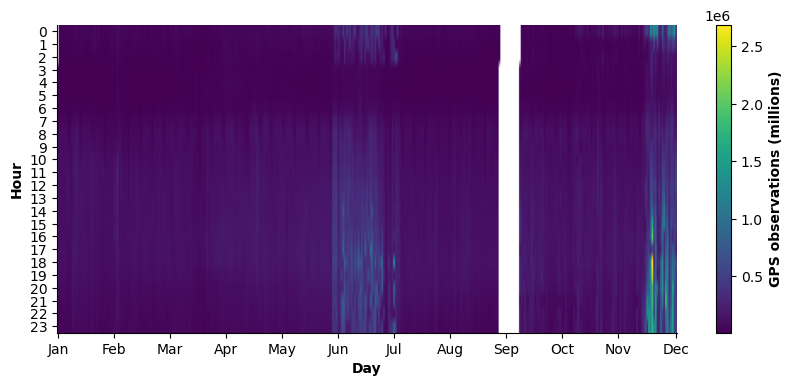

In [27]:
fig, ax, cbar = plot_hourly_doy_heatmap(df_temporal, value_col="n_points", figsize=(10, 4))
cbar.set_label("GPS observations (millions)", weight=600)
ax.set_xlabel("Day", weight=600)
ax.set_ylabel("Hour", weight=600);

**Figure 1.** Heatmap showing the total number of GPS points recorded for each hour of the day across the calendar year. The colorbar represents the absolute number of GPS observations (in millions), with lighter shades indicating higher volumes. White areas indicate periods with no recorded observations. 

In [ ]:
### clean dataset by removing "partial" days (i.e., 2023-09-18 00:00 - 2023-09-30 00:00)

In [28]:
df_temporal = df_temporal[df_temporal["date"] != pd.to_datetime("2023-09-18 00:00")]
df_temporal = df_temporal[df_temporal["date"] != pd.to_datetime("2023-09-30 00:00")]

#df_users = df_users[df_users["date"] != pd.to_datetime("2023-09-18 00:00")]
#df_users = df_users[df_users["date"] != pd.to_datetime("2023-09-30 00:00")]

df_user_daily_summary = df_user_daily_summary[df_user_daily_summary["date"] != pd.to_datetime("2023-09-18 00:00")]
df_user_daily_summary = df_user_daily_summary[df_user_daily_summary["date"] != pd.to_datetime("2023-09-30 00:00")]

df_spatial = df_spatial[df_spatial["date"] != pd.to_datetime("2023-09-18 00:00")]
df_spatial = df_spatial[df_spatial["date"] != pd.to_datetime("2023-09-30 00:00")]

df_spatial_daily_summary = df_spatial_daily_summary[df_spatial_daily_summary["date"] != pd.to_datetime("2023-09-18 00:00")]
df_spatial_daily_summary = df_spatial_daily_summary[df_spatial_daily_summary["date"] != pd.to_datetime("2023-09-30 00:00")]

### 3.4 Dataset Spatial Coverage

The dataset provides nationwide coverage of **Türkiye** at the latitude-longitude level and is aggregated by default to **H3 hexagons at resolution 7**, corresponding to an average cell area of approximately 5 km². Due to the availability of latitude-longitude coordinates, data can be re‑aggregated to any spatial resolution.

**Spatial coverage** is defined as the share of H3 hexes covering the national territory that record at least one observation over the year. Under this definition, the spatial coverage of the dataset is **67.92%**. As illustrated in Figure 2, hexes with no recorded observations are predominantly located in rural, mountainous, or sparsely populated areas, particularly in the eastern and central regions of the country.

In [29]:
100*len(df_spatial.groupby("hex_id")) / len(gdf_h3)

67.89771429689998

In [30]:
df_hex_avg_points_day = df_spatial.groupby("hex_id", as_index=False).mean()
gdf_map_spatial_coverage = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map_spatial_coverage["n_points"] = gdf_map_spatial_coverage["n_points"].fillna(0)

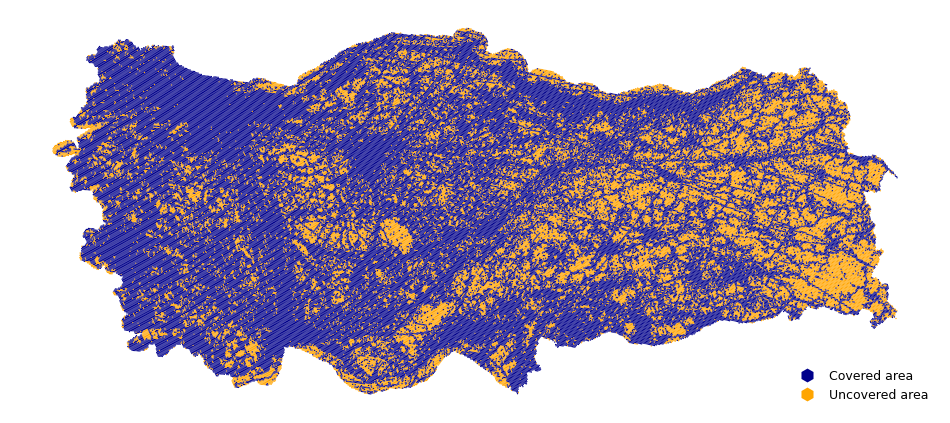

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), sharex=True)

gdf_map_spatial_coverage[gdf_map_spatial_coverage["n_points"]==0].plot(ax=ax, color="orange", edgecolor=None)
gdf_map_spatial_coverage[gdf_map_spatial_coverage["n_points"]>0].plot(ax=ax, color="darkblue", edgecolor=None)
ax.axis("off")

# Hexagon legend markers
legend_elements = [
    Line2D(
        [0], [0],
        marker='h',
        color='none',
        markerfacecolor='darkblue',
        markeredgecolor='none',
        markeredgewidth=0,
        markersize=10,
        label='Covered area',
    ),
    Line2D(
        [0], [0],
        marker='h',
        color='none',
        markerfacecolor='orange',
        markeredgecolor='none',
        markeredgewidth=0,
        markersize=10,
        label='Uncovered area',
    )
]

ax.legend(handles=legend_elements, loc="lower right", fontsize=9);


#fig, ax = plot_map_gdf(gdf_map_spatial_coverage[:1000], col="n_points", cmap="Blues", fig=fig, ax=ax[1])
#ax.set_title("Avg. points per hex (1y)");
#ax[1].axis("off");

**Figure 2.** Spatial coverage of H3 hexagons (resolution 7) in Türkiye, 2023. Hexagons that record at least one GPS observation during the year are shown in blue. Hexagons with no recorded observations are shown in orange. Spatial coverage is defined as the share of H3 hexagons with at least one observation over the study period.

## 4. Temporal Data Quality Assessment

This section examines the temporal dimension of the mobility dataset by analyzing daily activity levels, intra-day (hourly) patterns, and differences between weekdays and weekends. The analysis focuses on the evolution over time of the number of observations, active users, and visited spatial units, as well as on circadian mobility rhythms reflected in hourly distributions.
Taken together, these dimensions provide insight into the temporal stability and representativeness of the dataset and support the identification of temporal gaps, irregular sampling patterns, and structural changes in recording intensity that may affect downstream analyses.

### 4.1 Total Points, Unique Users, and Visited Hexes per Day

Figure 3 presents the daily time series of the number of GPS observations, unique active users, and unique visited hexagons over the study period.

**Baseline period**

For most of the observation period, both the number of observations and visited hexes remain relatively stable, with coefficients of variation (CV) of 22% and 11.8%, respectively. In contrast, the number of unique users exhibits greater day-to-day variability, with a CV of 52.82% during this time. We define the baseline period as the joint intervals from the beginning of the year until June 10 and from October 1 through December 12. This baseline represents the standard data-generation regime and serves as the reference for comparing anomalous phases.

**T1) Dense-User Tracking Period (11 June - 21 July)**

A clear structural break emerges on 11 June and persists until 21 July. During this interval, the number of GPS observations increases sharply, and the number of visited hexes rises substantially relative to the baseline regime (**+171%** and **+92%**, respectively), while the number of unique users declines markedly (**-30%**).

This divergence indicates that the observed increase in recorded activity is unlikely to reflect an actual rise in mobility. Instead, it supports the hypothesis of **denser tracking per user** (e.g., higher sampling frequency or a change in app behavior), rather than a real change in mobility. As a result, we observe more points and spatial units for a smaller user base. 


**T2) User-Drop Period (21 July - mid-September)**

Beginning on 21 July and lasting until the September data gap, the number of unique users collapses to extremely low levels compared to the baseline period (**-97%**, **from 250,000 to 7,500**) and remains structurally suppressed.
This is not a moderate decrease but a strong reduction in user coverage. Although observations and hex counts remain consistent with baseline levels, they operate on a drastically reduced user base. Based on the plot, this period should be characterized as a structural breakdown of data coverage and not just a decline in activity. The data-generation process appears severely disrupted during this interval.


**T3) Year-End Surge (13 December - 31 December)**

A second structural shift arises from 13 December onward. During this interval, the number of observations increases sharply, reaching the highest levels observed during the year (**+390%** compared to the baseline). Unlike the dense-user tracking period, this increase is accompanied by a strong increase in the number of unique users and a moderate expansion in spatial coverage. This pattern suggests an overall expansion in data volume driven by both user growth and higher observation intensity. The magnitude and abruptness of the increase point to a platform-level change in the user base and tracking rather than routine seasonal mobility variation.


In conclusion, the time series analysis reveals that the first part of the year and the period from October to mid-December are stable and consistent. In contrast, the mid-year interval is characterized by a dense-user tracking period (T1), followed by a user-drop period (T2) and a data gap in September, and finally by a year-end surge (T3). These structural shifts reflect changes in data generation rather than clear mobility dynamics. Consequently, any longitudinal analysis covering the second half of the year should be conducted with caution, applying appropriate normalization or adjustments to account for variations in tracking intensity and user coverage.
 
 
 
 
<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
    
| **Regime**      | **Main Signal**          | **Primary Driver**        | **Usability**                | **CV Points (%)** | **CV Users (%)** | **CV Hexes (%)** |
| --------------- | ------------------------ | ------------------------- | ---------------------------- | ----------------- | ---------------- | ---------------- |
| **Baseline**    | Stable across metrics    | Normal data regime        | High                         | 22.11             | 52.82            | 11.82            |
| **T1** | More points, fewer users | Higher tracking intensity | Medium (needs normalization) | 31.45             | 58.60            | 15.44            |
| **T2**   | Collapse in users        | Coverage breakdown        | Low                          | 20.17             | 13.74            | 11.64            |
| **T3**         | Surge in all metrics     | Platform-level expansion  | Medium (structural shift)    | 37.10             | 9.93             | 3.35             |


</div>
</div>

In [37]:
def rel_change(value, base):
    
    return 100*(value-base)/base

In [ ]:
rel_change(value=11199454.47, base=2284755.67)

In [ ]:
n_points
baseline 2284755.67
Summer_peak 6208125.66
user_flat 1959643.36
eoy 11199454.47

n_hexes_active
baseline 12401.85
Summer_peak 23759.22
user_flat 15811.78
eoy 13776.53

n_users
baseline 252158.37
Summer_peak 176205.63
user_flat 7661.9
eoy 419587.74

In [32]:
# The ranges are inclusive, i.e., [a, b]
dict_out_intervals = {"Summer_peak": ["2023-06-11", "2023-07-21"],
 "user_flat":["2023-07-21", "2023-09-18"],
 "eoy":["2023-12-13", "2023-12-31"]}

dict_interval_color = {"Summer_peak": "#e69f00",
 "user_flat":"#0072b2",
 "eoy":"#009e73"}

dict_interval_name = {"Summer_peak": "T1) Dense-User Tracking",
 "user_flat":"T2) User-Drop",
 "eoy":"T3) Year-End Surge"}

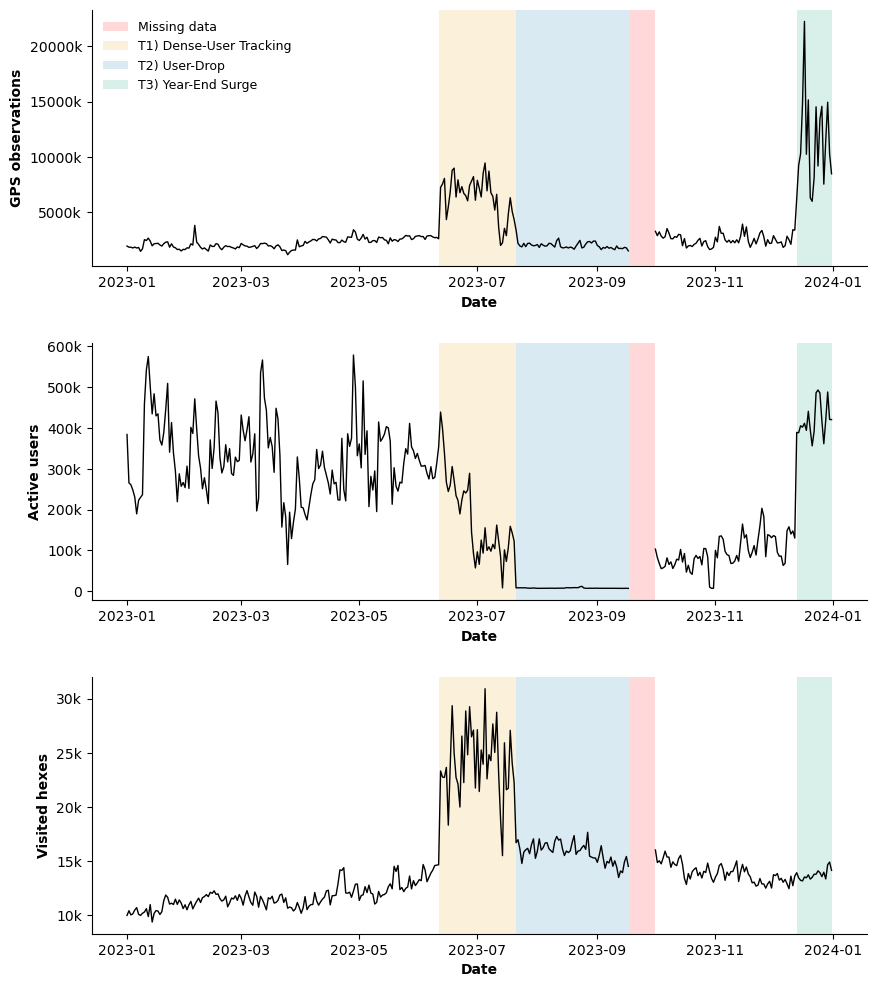

In [33]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=False, gridspec_kw={'hspace': 0.3})

x_points, y_points = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary["n_points"], freq="D")
axes[0].plot(x_points, y_points, c="k", linewidth=1)
axes[0].set_ylabel("GPS observations", weight=600);

x_users, y_users = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary["n_users"], freq="D")
axes[1].plot(x_users, y_users, c="k", linewidth=1)
axes[1].set_ylabel("Active users", weight=600);

x_hexes, y_hexes = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary["n_hexes_active"], freq="D")
axes[2].plot(x_hexes, y_hexes, c="k", linewidth=1)
axes[2].set_ylabel("Visited hexes", weight=600);

for ax in axes:
    ax.set_xlabel("Date", weight=600);
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))
    ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
    
    for interval_name, (interval_start, interval_end) in dict_out_intervals.items():

        ax.axvspan(pd.to_datetime(interval_end),
                   pd.to_datetime(interval_start),
                   color=dict_interval_color[interval_name],
                   alpha=0.15, linewidth=0, label=dict_interval_name[interval_name])

axes[0].legend(fontsize=9);

**Figure 3.** Daily time series of total GPS observations (top), number of unique active users (middle), and number of visited spatial units at H3 resolution 7 (bottom). Shaded regions indicate data regimes: baseline period (white), Dense-User Tracking Period (T1; orange), User-Drop Period (T2; blue), missing data interval (red), and Year-End Surge (T3; green).

In [34]:
def split_by_periods(df, periods, date_col):
    
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Ensure periods are datetime
    periods = [(pd.to_datetime(start), pd.to_datetime(end)) 
               for start, end in periods]

    # Collect period DataFrames
    period_dfs = []
    combined_mask = pd.Series(False, index=df.index)

    for start, end in periods:
        mask = (df[date_col] >= start) & (df[date_col] <= end)
        period_dfs.append(df.loc[mask])
        combined_mask |= mask

    # Baseline = not in any period
    baseline_df = df.loc[~combined_mask]

    return period_dfs, baseline_df

#### Relationships among Total GPS Points, Unique Users, and Unique Visited Hexes

To evaluate how the relationships among total GPS points, unique users, and unique visited hexes change over time, we compare their daily correlations across the identified "outlier" periods T1, T2, T3, and the baseline period (see Figure 4). This comparison helps determine whether observed changes in data volume reflect true mobility dynamics or simply variation in data collection intensity.

During the **baseline period** (black points), the three indicators follow a compact and consistent scaling structure that serves as the reference regime. GPS observations increase with visited hexagons. However, increases in the number of users do not systematically translate into broader spatial coverage, suggesting that additional users largely overlap in already active areas rather than expanding the spatial footprint.

In the **Dense-User Tracking Period (T1)** (orange points), the number of GPS observations is substantially higher than in the baseline regime, and spatial coverage expands disproportionately. At the same time, the user base declines. This pattern indicates higher observation intensity per user, consistent with denser tracking or increased sampling frequency rather than an actual increase in mobility.

During the **User-Drop Period** (blue points), the number of unique users collapses, while observations and visited hexagons persist but are generated by a much smaller participant base. This phase reflects a structural breakdown in user coverage instead of a gradual decline in activity.

The **Year-End Surge** (green points), unlike the dense-user tracking period, is characterized by simultaneous increases in users and observations, while spatial coverage remains broadly stable. This configuration suggests an overall expansion in data volume driven by a higher number of points associated with each user.

This finding highlights **temporal inconsistencies in data collection** and underscores that longitudinal analyses spanning these periods should apply appropriate normalization or regime-specific adjustments to ensure comparability.

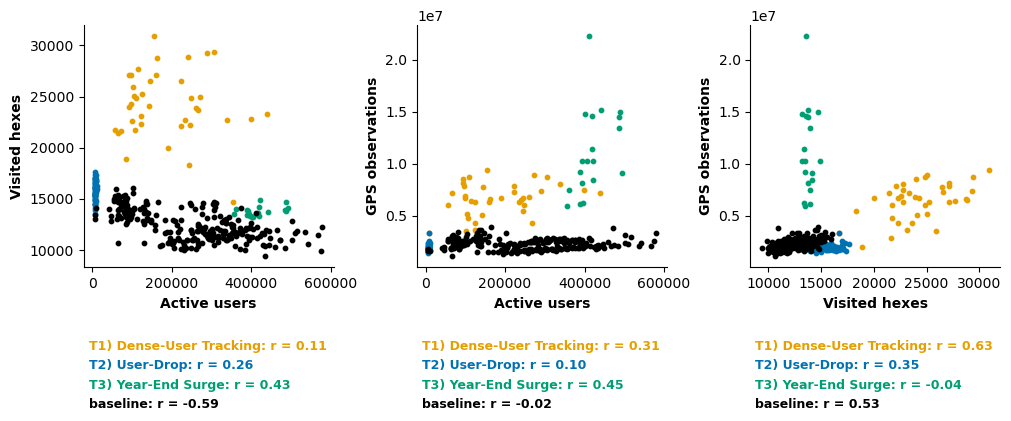

In [43]:
period_df_user, baseline_df_user = split_by_periods(df_user_daily_summary, list(dict_out_intervals.values()), "date")
period_df_spatial, baseline_df_spatial = split_by_periods(df_spatial_daily_summary, list(dict_out_intervals.values()), "date")

measure_to_label = {"n_users": "Active users",
                    "n_hexes": "Visited hexes",
                   "n_hexes_active": "Visited hexes",
                   "n_points": "GPS observations"}


# Prepare subplot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4),
                         constrained_layout=True, gridspec_kw={"hspace": 0.1, "wspace": 0})

pairs = list(combinations(["n_users", "n_hexes_active", "n_points"], 2))

for ind_measure, (m1, m2) in enumerate(pairs):

    ax = axes[ind_measure]
    corrs = []

    ax.set_xlabel(measure_to_label[m1], weight=600)
    ax.set_ylabel(measure_to_label[m2], weight=600)

    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if m1 == "n_hexes_active":
            x = period_df_spatial[ind_interval][m1]
        else:
            x = period_df_user[ind_interval][m1]

        if m2 == "n_hexes_active":
            y = period_df_spatial[ind_interval][m2]
        else:
            y = period_df_user[ind_interval][m2]

        ax.scatter(x, y, s=10, alpha=1, label=interval_name, color=dict_interval_color[interval_name])
        # Pearson correlation
        r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
        corrs.append((dict_interval_name[interval_name], r, dict_interval_color[interval_name]))


    # plot the baseline
    if m1 == "n_hexes_active":
        x = baseline_df_spatial[m1]
    else:
        x = baseline_df_user[m1]

    if m2 == "n_hexes_active":
        y = baseline_df_spatial[m2]
    else:
        y = baseline_df_user[m2]

    ax.scatter(x, y, s=10, alpha=1, label="baseline", c="k")
    # Pearson correlation
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    corrs.append(("baseline", r, "k"))

        

    # annotate inside plot (top-left corner)
    y_pos = -0.3
    for label, r, color in corrs:
        ax.text(
            0.02, y_pos,
            f"{label}: r = {r:.2f}",
            transform=ax.transAxes,
            fontsize=9,
            color=color,
            va="top",
            weight=600,
        )
        y_pos -= 0.08
        


**Figure 4.** Scatter plots illustrating the daily relationships among total GPS observations, number of unique users, and number of visited hexagons. Points are color-coded by regime (baseline, T1, T2, T3) to highlight differences in scaling patterns across periods.

In [36]:
for measure in ["n_points", "n_hexes_active",  "n_users"]:
    print(measure)

    #baseline
    if measure == "n_hexes_active":
        x_base = baseline_df_spatial[measure]
    else:
        x_base = baseline_df_user[measure]

    print("baseline", round(np.mean(x_base), 2))
    
    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if measure == "n_hexes_active":
            x = period_df_spatial[ind_interval][measure]
        else:
            x = period_df_user[ind_interval][measure]

        print(interval_name, round(np.mean(x), 2))
    print()


n_points
baseline 2284755.67
Summer_peak 6208125.66
user_flat 1959643.36
eoy 11199454.47

n_hexes_active
baseline 12401.85
Summer_peak 23759.22
user_flat 15811.78
eoy 13776.53

n_users
baseline 252158.37
Summer_peak 176205.63
user_flat 7661.9
eoy 419587.74



In [37]:
def coefficient_of_variation(data):
    data = np.array(data)
    mean = np.mean(data)
    if mean == 0:
        return np.nan  # Avoid division by zero
    std_dev = np.std(data, ddof=1)  # sample standard deviation
    cv = (std_dev / mean) * 100
    return cv



for measure in ["n_points", "n_hexes_active",  "n_users"]:
    print(measure)

    #baseline
    if measure == "n_hexes_active":
        x_base = baseline_df_spatial[measure]
    else:
        x_base = baseline_df_user[measure]

    cv = coefficient_of_variation(x_base)
    print("baseline", round(cv, 2))
    
    for ind_interval, interval_name in enumerate(dict_out_intervals.keys()):
        if measure == "n_hexes_active":
            x = period_df_spatial[ind_interval][measure]
        else:
            x = period_df_user[ind_interval][measure]

        cv = coefficient_of_variation(x)
        print(interval_name, round(cv, 2))
    print()


n_points
baseline 21.73
Summer_peak 31.45
user_flat 15.56
eoy 37.1

n_hexes_active
baseline 11.71
Summer_peak 15.44
user_flat 5.74
eoy 3.35

n_users
baseline 52.69
Summer_peak 58.6
user_flat 11.86
eoy 9.93



### 4.2 Circadian Rhythm: Hour-of-day Distributions

The hour‑of‑day distributions of points, active users, and active spatial hexes exhibit a circadian pattern, as shown in Figure 5. As expected, activity is lowest during nighttime hours, followed by an increase in the early morning, a sustained plateau from late morning through early evening, and a gradual decline thereafter. In addition, two local peaks are visible, corresponding to the morning and evening periods, a well-known feature of human mobility patterns. The consistency of these circadian profiles across indicators provides an important quality check, suggesting that despite temporal fluctuations in data volume, the dataset preserves realistic daily mobility rhythms {cite}`jiang2016timegeo`.

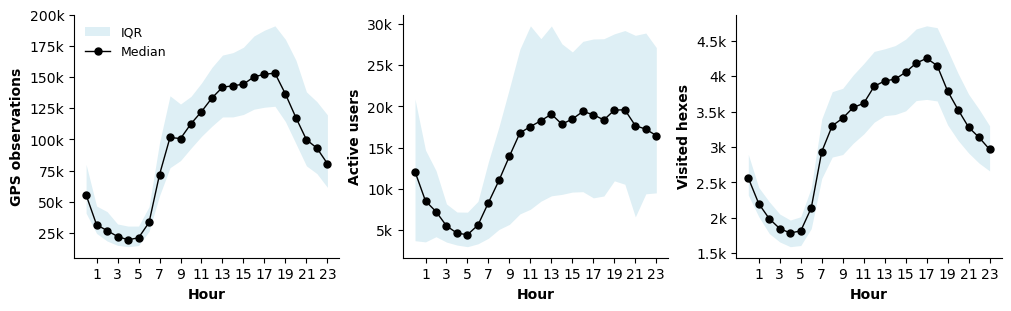

In [39]:
_, axes = plot_hourly_profiles(df_temporal, center="median", show_iqr=True, figsize=(10,3));

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

axes[0].legend(fontsize=9);

**Figure 5.** Average hourly distribution of total GPS observations, unique users, and active hexagons across all available days in 2023 (local time). Values are aggregated across the full observation period.

### 4.3 Weekend vs. Weekday

We also investigate how mobility and activity patterns differ between weekdays and weekends (Figure 6). During weekends, activity tends to start later in the morning, while the early-morning peak observed on weekdays is attenuated. Conversely, weekend activity exhibits a more pronounced increase during the afternoon and early evening.

In [44]:
temporal_daily_stats = df_temporal.copy()
temporal_daily_stats["dow"] = pd.to_datetime(temporal_daily_stats["date"]).dt.dayofweek # Mon=0 ... Sun=6
temporal_daily_stats["is_weekend"] = temporal_daily_stats["dow"] >= 5

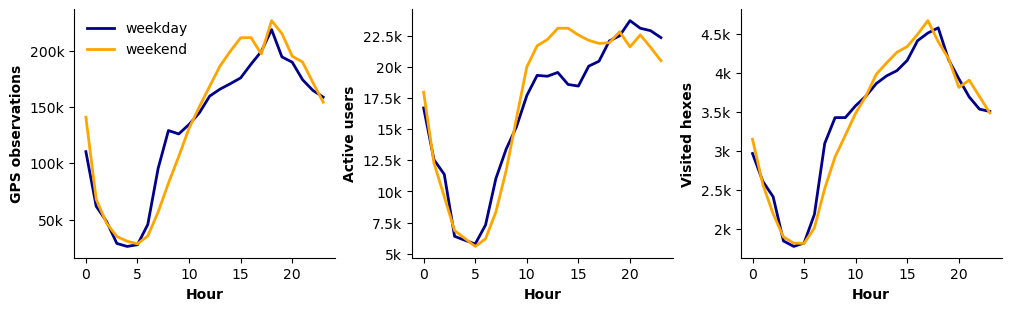

In [46]:
list_measures = ['n_points', 'n_users', 'n_hexes']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3),
                         constrained_layout=True, gridspec_kw={ "hspace": 0.1,"wspace": 0})

for ind_measure, measure in enumerate(list_measures):

    gb_week_vs_wend = temporal_daily_stats.groupby(["is_weekend", "hour"])[[measure]].mean().reset_index()

    for is_we, lab, col in [(False, "weekday", "darkblue"), (True, "weekend", "orange")]:
        gb_plot = gb_week_vs_wend[gb_week_vs_wend["is_weekend"] == is_we].sort_values("hour")
        axes[ind_measure].plot(gb_plot["hour"], gb_plot[measure], label=lab, color=col, linewidth=2)

    axes[ind_measure].set_ylabel(measure_to_label[measure], weight=600)
    axes[ind_measure].set_xlabel("Hour", weight=600)

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

axes[0].legend();

**Figure 6.** Comparison of mean hourly GPS observations between weekdays and weekends, aggregated over the study period. Curves reflect differences in intra-day activity profiles.

We further examined whether the weekday-weekend differences, which exhibit distinct intra-day circadian patterns, also translate into differences in the total number of observations within the same week. To assess this, we compared, for each week, the total number of observations recorded on weekdays versus weekends and computed the relative percentage difference. The results indicate that the number of observations during weekdays tends to be slightly higher than during weekends, with an average increase of 4-6%. However, this difference is not statistically significant when evaluated across weeks ([Wilcoxon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html) p ≈ 0.07; [t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) p ≈ 0.11).

In [47]:
df_tmp_sum = temporal_daily_stats.groupby("date", as_index=False).sum()

In [48]:
df_tmp_sum["num_week"] = df_tmp_sum["date"].apply(lambda x: x.weekofyear)
df_tmp_sum["is_weekend"] = df_tmp_sum["is_weekend"].apply(lambda x: int(x>0))
df_tmp_sum = df_tmp_sum[1:]

df_tmp_sum[:3]

,date,hour,n_points,n_users,n_hexes,dow,is_weekend,num_week
1,2023-01-02,276,1804776,386524,60996,0,0,1
2,2023-01-03,276,1808337,380524,60826,24,0,1
3,2023-01-04,276,1734967,360958,61087,48,0,1


In [49]:
df_pivot = df_tmp_sum.groupby(["num_week", "is_weekend"])[["n_points"]].mean().unstack("is_weekend")
df_pivot["pct_diff"] = (
    100*(df_pivot[("n_points", 0)] - df_pivot[("n_points", 1)]) 
    / df_pivot[("n_points", 1)]
)

df_pivot = df_pivot.dropna()

In [50]:
df_pivot["pct_diff"].mean(), df_pivot["pct_diff"].median()

(np.float64(6.153068009777183), np.float64(3.898526204700702))

In [51]:
from scipy.stats import ttest_1samp

ttest_1samp(df_pivot["pct_diff"], 0)

TtestResult(statistic=np.float64(1.6280046806564943), pvalue=np.float64(0.10993772806444808), df=np.int64(49))

In [52]:
from scipy.stats import wilcoxon

wilcoxon(df_pivot["pct_diff"])

WilcoxonResult(statistic=np.float64(450.0), pvalue=np.float64(0.07082612042920822))

### 4.4 Data Quality Implications

Temporal patterns in user counts, observation volumes, and spatial coverage reveal several important data quality considerations, particularly during the **T1 interval** (i.e., the Dense-User Tracking Period). Under stable sampling conditions, a true increase in mobility would be expected to coincide with stable or rising numbers of active users. The observed combination of declining user counts alongside increasing numbers of observations and visited hexes instead points to changes in tracking intensity or data ingestion processes, rather than to substantive behavioral shifts. As a result, absolute activity levels observed during peak periods are not directly comparable to those recorded during non-peak intervals.

Following the outlier interval T1, the number of users remains low until the September data gap, further limiting the reliability of user-based indicators during this period. Temporal comparisons spanning this phase should be avoided unless explicit adjustments are applied. We recommend treating September 18–30 as structurally missing and avoiding interpolation across this period, as it introduces a discontinuity in the data-generating process that may bias longitudinal comparisons.

The circadian and weekday vs. weekend patterns follow well‑established mobility rhythms, including morning and evening peaks. While this consistency supports the internal validity of the data, it also implies that comparisons across hours, days, or day types must be interpreted cautiously, as observed differences may reflect structural temporal rhythms rather than behavioral change.

For a robust temporal analysis, comparisons should be restricted to homogeneous temporal regimes (e.g., within the same outlier interval or stable-to-stable periods). Indicators should be normalized, and the September data gap should be explicitly excluded or adjusted. If these conditions are met, temporal patterns are stable and interpretable. In summary, longitudinal analyses should either exclude anomalous periods or rely on normalized metrics, such as adjustments by active-user counts, to ensure comparability and reduce sensitivity to variations in user coverage and tracking intensity, especially when comparing different time periods.


## 5. Spatial Data Quality Assessment

This section examines the spatial dimension of the mobility dataset by analyzing spatial coverage, concentration, and sparsity across H3 hexagonal units. The analysis focuses on the distribution of observations and users across space, the degree of spatial inequality, and the relationship between observed users and resident population.

Our analysis provides insight into the spatial representativeness and reliability of the data and support the identification of uneven coverage, highly concentrated activity patterns, and low-activity spatial units that may affect downstream spatial analyses and indicator construction.

### 5.1 Spatial Distribution

The map in Figure 7 illustrates the spatial distribution of mobility observations collected in 2023 across Türkiye, aggregated on an H3 hexagonal grid (resolution 7, ≈ 5.161 km² per hex) and expressed as the average number of points per hex during 2023.

As expected, observations are strongly concentrated around major urban centers, including Istanbul, Ankara, Izmir, and other metropolitan areas. This spatial pattern reflects higher population density and activity levels in urban environments. In contrast, rural and sparsely populated regions exhibit lower observation volumes, consistent with demographic distributions.

A non‑negligible number of observations are detected over water bodies, particularly in coastal areas such as the sea in front of Istanbul. These observations are plausibly explained by individuals carrying GPS‑enabled devices while traveling by ferry, boat, or ship. A further notable feature is the presence of a distinct linear structure in the eastern part of the map. This straight‑line pattern does not correspond to known road infrastructure and is therefore unlikely to reflect ground transportation. A plausible interpretation is that these observations were recorded along an air travel corridor, where GPS positions are intermittently logged during flights. Such artifacts should be explicitly accounted for or filtered in downstream spatial analyses.

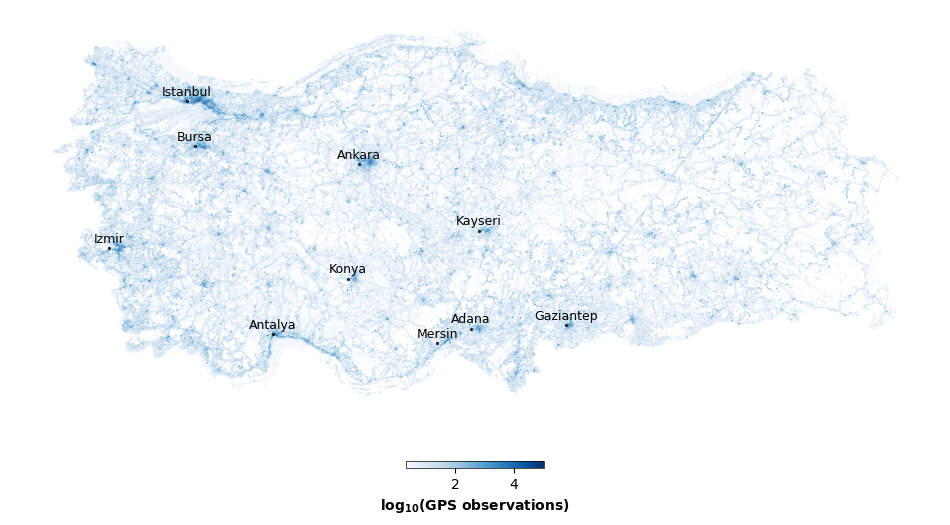

In [54]:
fig, ax, cbar = plot_map_gdf(gdf_map_spatial_coverage, col="n_points", cmap="Blues", vmin=1, figsize=(12, 6))
ax.axis("off");
cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5)    

cities_annotate = {
    "Istanbul": (41.004852, 28.682533), "Ankara": (39.9032599, 32.5979554), "Izmir": (38.4175596,26.9149073),
    "Bursa": (40.2215611,28.8674802), "Antalya": (36.8979091,30.6357038), "Adana": (36.9973011,35.123257),
    "Gaziantep": (37.058743,37.2977357), "Konya": (37.8783916,32.3416727), "Kayseri": (38.7232853,35.3053774),
    "Mersin": (36.7426015,34.3640958)}

for city in cities_annotate:
    lat, lon = cities_annotate[city]
    ax.scatter(lon, lat, s=2, color="black", alpha=0.7, zorder=3)
    ax.text(lon, lat+0.05, city, fontsize=9, fontweight='500', ha="center", va="bottom", color="black", zorder=5)

**Figure 7.** Spatial distribution of GPS observations shown as the *average annual number of records per H3 hexagon (resolution 7)*. Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations.


### 5.2 Total Points and Unique Users per Visited Spatial Unit

Each spatial unit corresponds to an H3 hexagon at resolution 7 (see the figure below for an illustrative example). Overall, daily activity at the hex level is typically low. On average, each spatial unit (i.e., a hex or hexagon) contains approximately 220 points generated by 20 users. However, these values decrease substantially when considering the median: in the median case, a hexagon contains 15 points generated by 2 users. The average number of users per hexagon is 20.44. The pronounced gap between the mean and the median reflects a strongly right-skewed spatial distribution.

In [56]:
round(gdf_map_spatial_coverage, 0).sort_values("n_points", ascending=False)[:1].explore(tooltip=["h3_index", "n_points"])

In [57]:
df_spatial_gb_avg = df_spatial.groupby(["date", "hex_id"], observed=True, as_index=False).mean()

dict_SDS_mean = df_spatial_daily_summary.mean().to_dict()
print("--- Averages per hex per day ---")
print("measure")
print("avg. points:\t", round(df_spatial_gb_avg["n_points"].mean(), 2))
print("avg. users:\t", round(df_spatial_gb_avg["n_users"].mean(), 2))

print()
df_spatial_gb_median = df_spatial.groupby(["date", "hex_id"], observed=True, as_index=False).median()
print("--- Medians per hex per day ---")
print("median points:\t", round(df_spatial_gb_median["n_points"].median(), 2))
print("median users:\t", round(df_spatial_gb_median["n_users"].median(), 2))

--- Averages per hex per day ---
measure
avg. points:	 220.46
avg. users:	 20.44

--- Medians per hex per day ---
median points:	 15.0
median users:	 2.0


The time series of points- and users‑per‑hex metrics (Figure 8, left and right, respectively) remain broadly stable over the year. During the Dense-User Tracking Period (T1), most visible in the upper quantiles, there is increased spatial concentration of activity, whereby fewer users are tracked more intensively within a limited subset of locations. Outside of this period, no major structural changes in spatial intensity are observed.

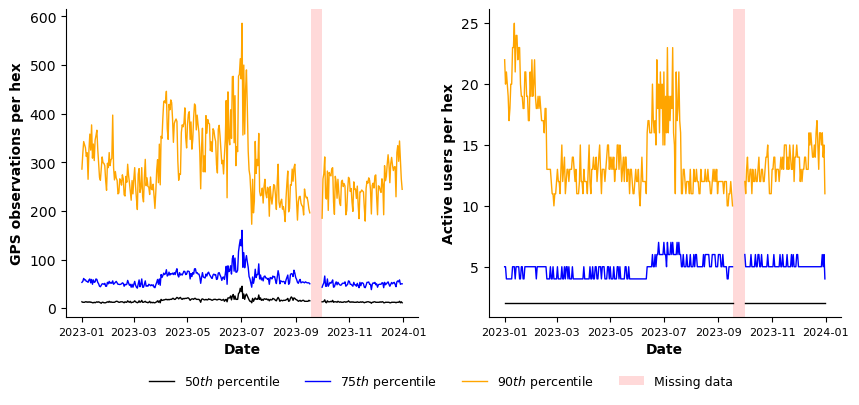

In [59]:
colors = ["k", "blue", "orange"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharex=False)

# points
cols = ["p50_points_hex", "p75_points_hex", "p90_points_hex"]
for col, color in zip(cols, colors):

    label = f"{int(col[1:3])}$th$ percentile"    
    x_points, y_points = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary[col], freq="D")
    axes[0].plot(x_points, y_points, c=color, label=label, linewidth=1)

axes[0].set_xlabel("Date", weight=600)
axes[0].set_ylabel("GPS observations per hex", weight=600)
axes[0].axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")

# users
cols = cols = ["p50_users_hex", "p75_users_hex", "p90_users_hex"]
for col, color in zip(cols, colors):
    x_users, y_users = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary[col], freq="D")
    axes[1].plot(x_users, y_users, c=color, linewidth=1)

axes[1].set_xlabel("Date", weight=600)
axes[1].set_ylabel("Active users per hex", weight=600)
axes[1].axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0)

axes[0].tick_params(axis='x', labelsize=8)
axes[1].tick_params(axis='x', labelsize=8)

fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),   # centered between the two axes
    bbox_transform=fig.transFigure,
    ncol=4,
    frameon=False,
    fontsize=9
);

**Figure 8.** Daily values of points per hexagon (left) and users per hexagon (right). The black line represents the 50th percentile (median), the blue line the 75th percentile, and the orange line the 90th percentile. The shaded area indicates periods of missing data.

### 5.3 Inequality of Distribution of Observations across Spatial Units


We analyze the distribution of observations across spatial units (H3 hexes) to assess the degree of spatial inequality, as most hexes receive very few observations, while a small fraction concentrates a disproportionately large share of GPS points.

This inequality is evident in both the rank-size distribution (Figure 9, left), which displays a heavy‑tailed behavior, and in the Lorenz curve (Figure 9, right), having an associated Gini coefficient of 0.85, indicating spatial concentration of activity within a small number of hexes. This level of inequality is expected in human mobility data, where visit frequencies are well known to follow power‑law or heavy‑tailed distributions. Empirical studies based on large‑scale GPS and mobile phone data consistently show that most locations are visited infrequently, while a small number of highly attractive locations accumulate the majority of visits {cite}`gonzalez2008understanding, barbosa2018human`.

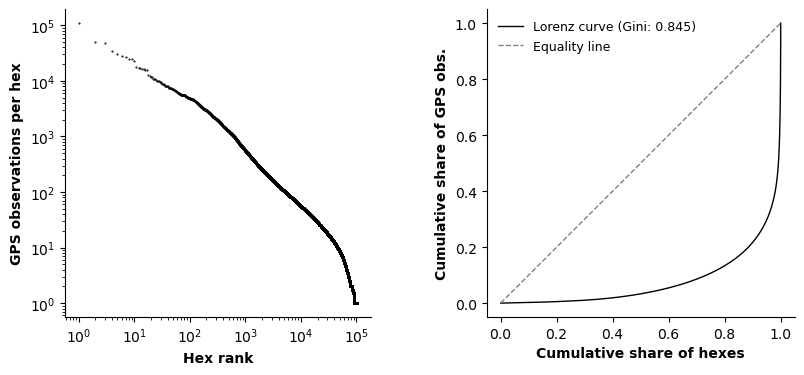

In [61]:
df_spatial_gb_avg = df_spatial.groupby(["hex_id"], as_index=False).agg(n_points=("n_points", "mean"))
df_spatial_gb_avg = df_spatial_gb_avg.sort_values("n_points", ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Rank
ranks = np.arange(1, len(df_spatial_gb_avg) + 1)
values = df_spatial_gb_avg["n_points"].values

#Rank–size plot (log–log)
axes[0].loglog(ranks, values, c="k", marker=".", linestyle="none", markersize=1)
axes[0].set_xlabel("Hex rank", weight=600)
axes[0].set_ylabel("GPS observations per hex", weight=600)
#ax[0].set_title("Rank–size distribution of GPS points per hex")

# Lorenz curve

# one-curve per day
'''
list_gini = []
for date, g in df_spatial.groupby("date"):
    values = np.sort(g["n_points"].values)
    cum_points = np.cumsum(values)
    cum_points = cum_points / cum_points[-1]
    cum_hexes = np.arange(1, len(values) + 1) / len(values)
    ax[1].plot(cum_hexes, cum_points, c="lightgrey", linewidth=0.1, alpha=0.5)
    list_gini.append(gini(values))
'''


# aggregated curve
values = np.sort(df_spatial_gb_avg["n_points"].values)
cum_points = np.cumsum(values)
cum_points = cum_points / cum_points[-1]

cum_hexes = np.arange(1, len(values) + 1) / len(values)
gini_score = round(gini(values), 3)
axes[1].plot(cum_hexes, cum_points, label=f"Lorenz curve (Gini: {gini_score})", c="k", linewidth=1)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Equality line", linewidth=1)
axes[1].set_xlabel("Cumulative share of hexes", weight=600)
axes[1].set_ylabel("Cumulative share of GPS obs.", weight=600)
#ax[1].set_title("Lorenz curve of GPS points per hex")
axes[1].legend(loc="upper left", fontsize=9)

for ax in axes:
    ax.set_aspect('equal')

**Figure 9.** Rank-size distribution of total GPS observations per H3 hexagon, illustrating a pronounced heavy-tailed distribution (left).
Lorenz curve showing the cumulative share of observations by ranked hexagons (right), with the corresponding Gini coefficient (0.85) quantifying the high degree of spatial inequality in activity concentration.

We further characterize spatial inequality by examining the share of total observations captured by the most frequently visited hexes. The results shown in Figure 10 highlights that the **top 1% of hexes** consistently **account for about 40% of all GPS points**, highlighting an extreme concentration of activity. Expanding to the top 2% and 5% of hexes substantially increases the cumulative share, confirming that overall visitation is dominated by a very small fraction of locations.

This concentration pattern is stable over time, with only moderate fluctuations that mirror previously identified temporal dynamics in data capture. The persistence of these shares indicates that spatial inequality is a structural property of the dataset, rather than the result of short-term shocks or transient changes in mobility behavior.

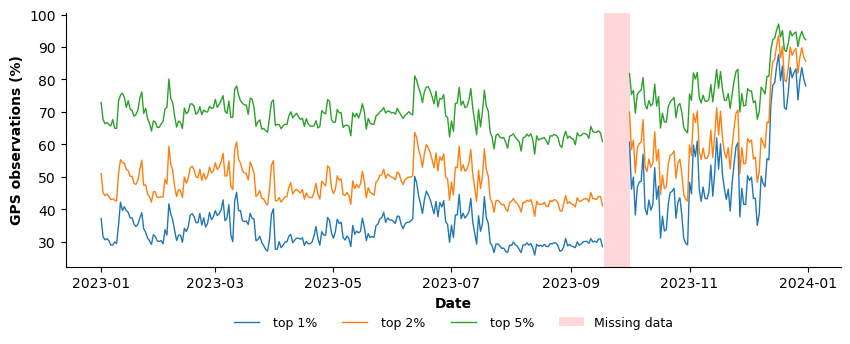

In [64]:
def top_pct_share(s):
    m = len(s)
    k = max(1, int(np.ceil(m * pct)))
    return s.nlargest(k).sum() / s.sum()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

for pct in [0.01, 0.02, 0.05]:
    
    result = df_spatial.groupby("date")["n_points"].apply(top_pct_share).rename("share_pct").reset_index()

    x_share, y_share = fill_time_gaps(result["date"], result["share_pct"], freq="D")
    
    ax.plot(x_share,100*y_share, label=f" top {int(100*pct)}%", linewidth=1)

ax.set_xlabel("Date", weight=600);
ax.set_ylabel("GPS observations (%)", weight=600);
ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 10.** Time series of the share of total GPS observations captured by the highest-ranked H3 hexagons at different thresholds: top 1% (blue), top 2% (orange), and top 5% (green) most visited hexagons.

### 5.4 Spatial Representativeness

In [ ]:
import rasterio
from rasterstats import zonal_stats

In [ ]:
worldpop_path = "./shape_files/tur_pop_2023_CN_100m_R2025A_v1.tif"

# Load world pop raster
with rasterio.open(worldpop_path) as src:
    data = src.read(1)
    nodata = src.nodata
    raster_crs = src.crs

print("raster no data:", nodata)
print("raster crs:", raster_crs)

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap="viridis")

In [67]:
avg_measures_per_hex = df_spatial.groupby(["hex_id"], as_index=False).mean()[["hex_id", "n_points", "n_users"]]

In [ ]:
gdf_h3[:1]

_Exe time: 10 mins_

In [ ]:
%%time

stats = zonal_stats(gdf_h3.geometry, worldpop_path, stats=["sum"], nodata=nodata, dtype="float64", all_touched=True)

gdf_h3["population"] = [0 if s["sum"] is None or s["sum"] < 0 else s["sum"] for s in stats]

In [ ]:
gdf_h3[:1]

In [ ]:
#gdf_h3.to_file("./spatial_tessellations/gdf_h3_population.geojson", driver="GeoJSON")

In [65]:
gdf_h3 = gpd.read_file("./spatial_tessellations/gdf_h3_population.geojson")

In [68]:
df_points_po = avg_measures_per_hex.merge(gdf_h3[['h3_index', 'population']],left_on='hex_id', right_on="h3_index", how='inner')

GPS observations are collected through GPS-enabled devices and therefore represent only a subset of the total population within the study area. Specifically, they capture individuals who own smartphones, have specific applications installed, and have enabled location-sharing permissions accessible to the data provider. Consequently, the derived mobility metrics should not be interpreted as measures of the true total population. Rather, they serve as high-frequency proxies for the spatial and temporal distribution of observed device users.

To assess spatial representativeness and identify potential representation bias, we examine the relationship between the **resident population** and **observed users** at the H3 hexagon level. Specifically, we correlate the average daily number of unique users per hexagon with the corresponding resident population counts (data extracted from [WorldPop](https://hub.worldpop.org/geodata/summary?id=75773)). At the aggregate level, population and observed users exhibit a moderate positive association (Figure 11; Pearson's **r ≈ 0.48**), suggesting that **more populous areas tend to register higher numbers of observed users**, albeit with substantial spatial variability.


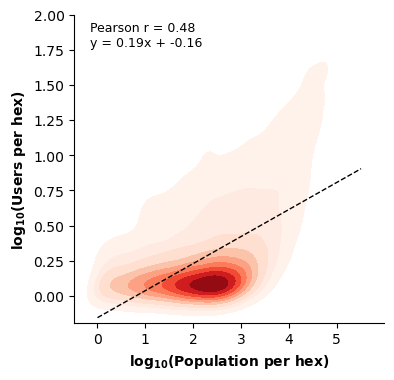

In [70]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

# keep only positive values (for the log)
df_plot_xy = df_points_po[(df_points_po["population"] > 1) &(df_points_po["n_users"] > 1)]

# log10 transform
x = np.log10(df_plot_xy["population"])
y = np.log10(df_plot_xy["n_users"])

# scatter

sns.kdeplot(x=x, y=y, fill=True, cmap="Reds")
ax.set_xlabel(r"$\mathbf{log_{10}}$(Population per hex)", weight=600)
ax.set_ylabel(r"$\mathbf{log_{10}}$(Users per hex)", weight=600)

# Pearson on log-log
pearson_corr, pearson_p = pearsonr(x, y)

# Linear fit in log-log space
slope, intercept = np.polyfit(x, y, 1)
# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='k', lw=1, linestyle="--")

# Pearson correlation and regression equation
pearson_text = f"Pearson r = {pearson_corr:.2f}\n" \
               f"y = {slope:.2f}x + {intercept:.2f}"

ax.text(0.05, 0.98, pearson_text, transform=ax.transAxes,
        fontsize=9, color="k", va="top", weight=400);

ax.set_ylim(None, 2);

#print("Pearson r:", pearson_corr)
#print("p-value:", pearson_p)

**Figure 11.**
Bivariate kernel density plot of resident population estimates (WorldPop) versus the average daily number of unique users per H3 hexagon (Pearson correlation, *r* ≈ 0.48). The dashed line represents the linear fit. Red color intensity corresponds to higher point density.

#### Population-Mobility Scaling by Urbanization Level

To better characterize heterogeneity in the **population-mobility relationship**, we stratify H3 hexagons by **level of urbanization** using population‑based quantiles (Figure 12), with thresholds chosen as analytical assumptions. Specifically, hexes are classified as:

- **Rural** hexagons: bottom **40%** of the population distribution, representing low‑density areas.
- **Suburban (peri‑urban)** hexagons: middle **40%**, capturing transitional zones between rural and urban areas.  
- **Urban** hexagons: top **20%**, characterized by high population density

For each class, we compute **Pearson correlation coefficients** (see Figure 13). From our analysis, differences emerge across urbanization levels. In **rural and suburban hexes**, correlations are weak and scaling exponents are close to zero, indicating a **limited coupling between resident population and observed users**. In contrast, **urban hexes exhibit a strong positive association** (**r ≈ 0.72**) and a clear scaling relationship, reflecting a more systematic alignment between population density and user presence in **urban environments**.

In [71]:
df_points_po[:1]

,hex_id,n_points,n_users,h3_index,population
0,871ec8000ffffff,13.0,1.0,871ec8000ffffff,16.848186


In [72]:
df_urban_areas = df_points_po[df_points_po["population"] > 1].copy()

q1 = df_urban_areas["population"].quantile(0.4)
q2 = df_urban_areas["population"].quantile(0.8)

df_urban_areas["zone"] = np.where(df_urban_areas["population"] <= q1, "rural", np.where(df_urban_areas["population"] <= q2, "suburban", "urban"))

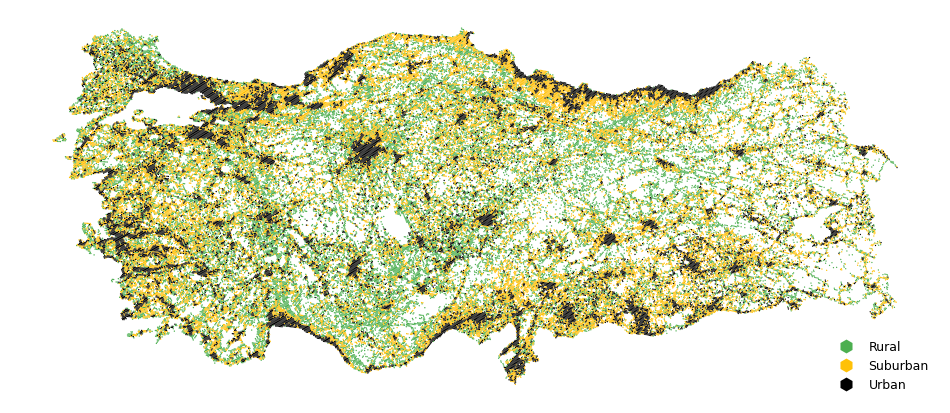

In [73]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
for hex_type, col in zip(["rural", "suburban", "urban"], ["#4CAF50", "#FFC107", "k"]):
    set_hex_ids = set(df_urban_areas[df_urban_areas["zone"]==hex_type]["hex_id"])
    gdf_h3[gdf_h3["h3_index"].isin(set_hex_ids)].plot(ax=ax, color=col)

ax.axis("off")
legend_elements = [ 
    Line2D([0], [0],marker='h',color='none',markerfacecolor=col,markeredgecolor='none',markeredgewidth=0,
        markersize=10,label=hex_type.title()) for hex_type, col in zip(["rural", "suburban", "urban"], ["#4CAF50", "#FFC107", "k"])]

ax.legend(handles=legend_elements, loc="lower right", fontsize=9);

**Figure 12.**
Spatial classification of H3 hexagons into rural (green), suburban (yellow), and urban (black) categories across the study area. The map highlights the extensive coverage of rural hexagons, with suburban areas forming transition zones around major urban centers, and urban hexagons concentrated in densely populated metropolitan regions.

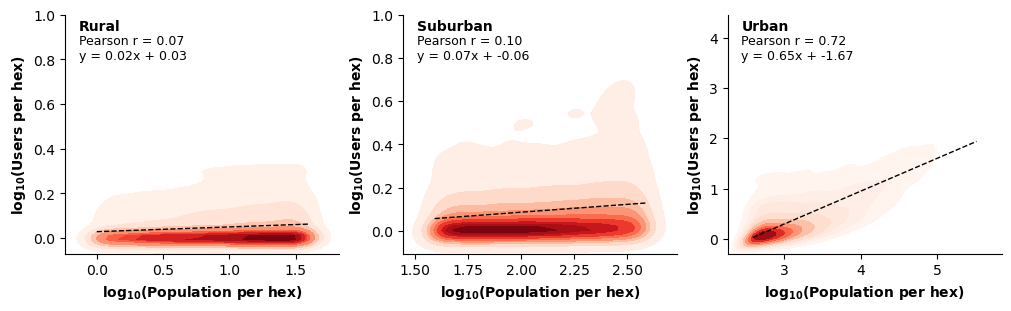

In [74]:
zones = ["rural", "suburban", "urban"]

# Prepare subplot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3),
                         constrained_layout=True, gridspec_kw={"hspace": 0.1, "wspace": 0})

for i, zone in enumerate(zones):
    df_zone = df_urban_areas[df_urban_areas["zone"] == zone]

    # log10 transform
    x = np.log10(df_zone["population"])
    y = np.log10(df_zone["n_users"])

    # Pearson correlation
    r, _ = pearsonr(x, y)
    
    # Linear fit in log-log space
    slope, intercept = np.polyfit(x, y, 1)

    # scatter
    #axes[i].scatter(x, y, s=1, alpha=0.1, color='k')
    sns.kdeplot(x=x, y=y, fill=True, cmap="Reds", ax=axes[i])
    
    # regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    axes[i].plot(x_line, y_line, color='k', lw=1, linestyle="--")

    axes[i].set_xlabel(r"$\mathbf{log_{10}}$(Population per hex)", weight=600)
    axes[i].set_ylabel(r"$\mathbf{log_{10}}$(Users per hex)", weight=600)

    # Pearson correlation and regression equation
    pearson_text = f"Pearson r = {r:.2f}\n" \
                   f"y = {slope:.2f}x + {intercept:.2f}"

    axes[i].text(0.05, 0.98, zone.capitalize(), transform=axes[i].transAxes,
            fontsize=10, color="k", va="top", weight=600)
    axes[i].text(0.05, 0.92, pearson_text, transform=axes[i].transAxes,
            fontsize=9, color="k", va="top", weight=400)

    if i < 2:
        axes[i].set_ylim(None, 1)  


**Figure 13.**
Bivariate kernel density plots and fitted linear relationships between resident population and observed users for rural, suburban, and urban H3 hexagons (defined by population quantiles).

### 5.5 Effects of User and Point Thresholds on Spatial Units

Only a limited share of hexes exhibits very low daily activity. As Figure 14 shows, on average, approximately 6.9% of hexes record at most one point per day, increasing to 14.0% for ≤2 points and 27.5% for ≤5 points.

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Points per Hex | Share of Hexes (%) |
| :----------------------: | :-------------------: |
| ≤ 1                      | 6.91 ± 2.19           |
| ≤ 2                      | 14.02 ± 2.39          |
| ≤ 5                      | 27.46 ± 4.52          |

</div>
</div>



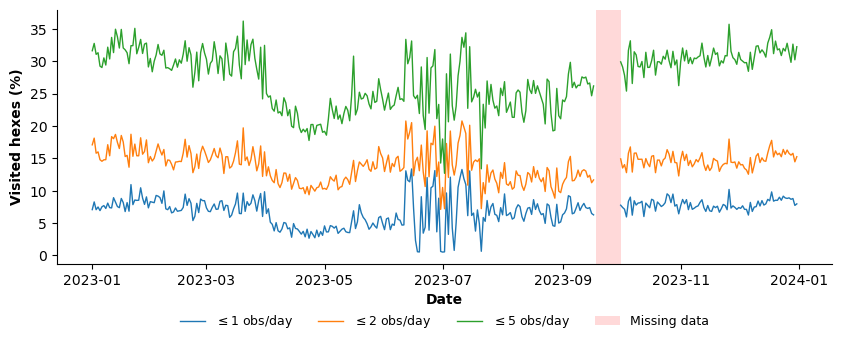

In [79]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_ths = [1,2,5]
for th in list_ths:

    v_noise_pct = 100*(df_spatial_daily_summary[f"n_hexes_points_le_{th}"]/df_spatial_daily_summary["n_hexes_active"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)

    #print(f"hexes with <= {th} points {noise_avg} % (±{noise_std})")

    x_th, y_th = fill_time_gaps(df_spatial_daily_summary["date"], v_noise_pct.values, freq="D")
    
    ax.plot(x_th, y_th, label=f"$\leq${th} obs/day", linewidth=1)
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Visited hexes (%)", weight=600);

ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 14.**
Time series of the share of H3 hexagons recording ≤1 (blue), ≤2 (orange), and ≤5 (green) GPS points. The figure illustrates the proportion of low-activity hexagons over time.


In addition, a substantial fraction of hexes is visited by very few unique users (Figure 15). On average, approximately 41.5% of hexes record visits from at most one user per day, increasing to 58% for ≤2 users and 67.1% for ≤3 users. This indicates that many spatial units are characterized by highly localized or sporadic usage, often driven by a very small number of individuals rather than by broad user participation.

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Users per Hex| Share of Hexes (%) |
| :-------------------------:| :-------------------: |
| ≤ 1                        | 41.45 ± 2.82          |
| ≤ 2                        | 58.00 ± 3.16          |
| ≤ 3                        | 67.14 ± 3.04          |

</div>
</div>

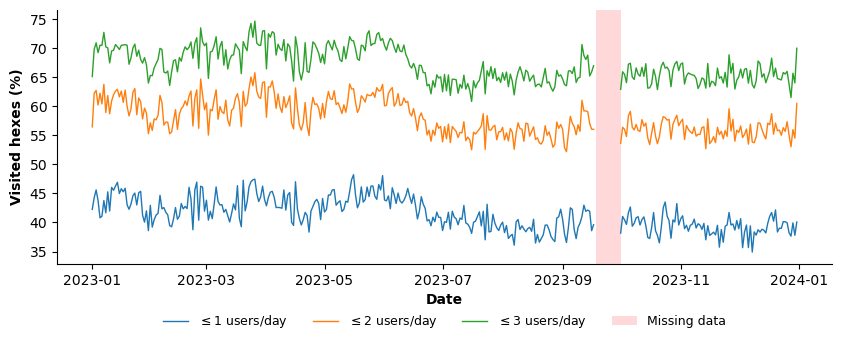

In [81]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2,3]
for th in list_ths:

    v_noise_pct = 100*(df_spatial_daily_summary[f"n_hexes_users_le_{th}"]/df_spatial_daily_summary["n_hexes_active"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    #print(f"hexes with <= {th} users {noise_avg} % (±{noise_std})")
    
    x_th, y_th = fill_time_gaps(df_spatial_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} users/day", linewidth=1)
    
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Visited hexes (%)", weight=600);

ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False, fontsize=9);

**Figure 15.**
Time series of the share of H3 hexagons visited by ≤1 (blue), ≤2 (orange), and ≤5 (green) unique users.


### 5.6 Data Quality Implications

The spatial distribution of observations is consistent with known mobility patterns, with spatial activity concentrated in metropolitan areas. This alignment supports the dataset's spatial reliability. The presence of observations over water bodies and along linear trajectories indicates that raw spatial traces include movement-related artifacts (e.g., ferry routes or air travel). Depending on the analytical objective, these artifacts can be explicitly filtered, as they do not represent stationary activity at those locations.

The distribution of visits across hexes is highly skewed, with a small number of locations accounting for a large share of total activity. This heavy-tailed structure is a well-established mobility feature and should be interpreted as a realism check rather than a data-quality issue. However, it has important analytical implications: simple averages are dominated by high-activity hexes, and distribution-aware metrics (such as medians, quantiles, or inequality measures) are more appropriate for spatial characterization.

Spatial representativeness varies systematically with urbanization level. Coverage is strongest in dense urban areas and substantially weaker in low-density rural regions. Analyses at H3 resolution 7 (or higher) are reliable primarily in urban cores; in rural and peripheral areas, spatial aggregation (e.g., resolution 6 or higher-level administrative units) is required to obtain stable, interpretable signals.

## 6. User Activity Assessment

This section examines the user-level dimension of the dataset by analyzing patterns of activity, spatial behavior, and contribution inequality across individuals. Specifically, we investigate the distribution of observations per user, the prevalence of sparse daily traces, and the extent to which user activity is spatially localized.

Given that our primary objective is to construct an Urban Space Index, we do not focus on individual mobility descriptors such as radius of gyration, nor do we attempt to characterize users’ mobility through detailed trajectory reconstruction. Instead, our analysis emphasizes aggregated behavioral patterns that are directly relevant to the proposed index.

In [82]:
dict_UDS_mean = df_user_daily_summary.mean().to_dict()
print("--- Averages per user per day ---")
print("measure")
print("avg. points:\t", round(dict_UDS_mean["avg_points"], 2))
print("avg. visits:\t", round(dict_UDS_mean["avg_hexes"], 2))
print("avg. time win:\t", round(dict_UDS_mean["avg_active_win"], 2), "min")

print()
dict_UDS_median = df_user_daily_summary.median().to_dict()
print("--- Medians per user per day ---")
print("p50 points:\t", round(dict_UDS_median["p50_points"], 2))
print("p50 visits:\t", round(dict_UDS_mean["p50_hexes"], 2))
print("p50 time win:\t", round(dict_UDS_mean["p50_active_win"], 2), "min")

--- Averages per user per day ---
measure
avg. points:	 61.05
avg. visits:	 3.13
avg. time win:	 300.7 min

--- Medians per user per day ---
p50 points:	 3.0
p50 visits:	 1.2
p50 time win:	 208.76 min


### 6.1 Total Points, Visited Hexes, and Active Window per User

User-level activity exhibits strong heterogeneity, as evident in Figure 16. The median user records approximately 3 GPS points, 1 visited location, and 208 minutes of observed activity per day, while mean values are substantially higher: 61 GPS points, 3 locations, and 300 minutes. This pronounced gap between the median and the mean implies a right-skewed distribution, in which a small share of highly active users accounts for most of the observations. In contrast, the majority of users generate sparse, discontinuous daily traces.

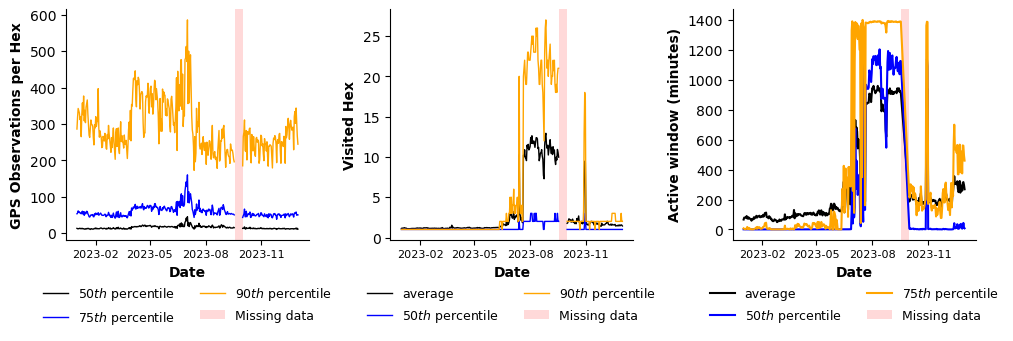

In [85]:
cols = ["p50_points_hex", "p75_points_hex", "p90_points_hex"]
colors = ["k", "blue", "orange"]

# Prepare subplot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.3),
                         constrained_layout=True, gridspec_kw={"hspace": 0, "wspace": -1})

# points
for col, color in zip(cols, colors):
    label = f"{int(col[1:3])}$th$ percentile" 
    
    x_points, y_points = fill_time_gaps(df_spatial_daily_summary["date"], df_spatial_daily_summary[col], freq="D")
    axes[0].plot(x_points, y_points, c=color, label=label, linewidth=1)
axes[0].set_ylabel("GPS Observations per Hex", weight=600)


# visited hex
cols = ["avg_hexes", "p50_hexes", "p90_hexes"]
for col, color in zip(cols, colors):
    
    if "p" in col:
        label = f"{int(col[1:3])}$th$ percentile" 
    else:
        label = "average"
        
    x_hexes, y_hexes = fill_time_gaps(df_user_daily_summary["date"], df_user_daily_summary[col], freq="D")
    axes[1].plot(x_hexes, y_hexes, c=color, label=label, linewidth=1)
axes[1].set_ylabel("Visited Hex", weight=600)

# active win
cols = ["avg_active_win", "p50_active_win", "p75_active_win"]
for col, color in zip(cols, colors):
    if "p" in col:
        label = f"{int(col[1:3])}$th$ percentile" 
    else:
        label = "average"
        
    axes[2].plot(df_user_daily_summary["date"], df_user_daily_summary[col], c=color, label=label)
axes[2].set_ylabel("Active window (minutes)", weight=600)

#for ax in axes:
#    ax.axvspan(pd.to_datetime('2023-09-19'), pd.to_datetime('2023-09-29'),color='red', alpha=0.2)
#    ax.set_xlabel("Date", weight=600)
#    ax.legend()

for ax in axes:
    ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel("Date", weight=600)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

**Figure 16.** Daily values of GPS points per H3 hexagon (left), number of visited hexagons (middle), and active window in minutes (right). Lines represent selected quantiles (50th, 75th, and 90th percentiles as indicated) and the mean where shown. The shaded area denotes periods of missing data.

### 6.2 Inequality of Distribution of Observations across Users

We assess user‑level contribution patterns to evaluate the degree of user‑representation inequality in the dataset. The distribution of GPS observations across users is highly uneven: most users contribute relatively few observations, while a small fraction of highly active users accounts for a disproportionate share of all recorded points.

This imbalance is clearly visible in the rank-size distribution, which exhibits a pronounced heavy-tailed shape, indicating differences between low- and high-contributing users (Figure 17, left). Consistently, the Lorenz curve diverges from the equity line, with an associated Gini coefficient of 0.583, highligting strong concentration of observations among a small share of users (Figure 17, right).

From a data quality perspective, this pattern is typical of passively collected mobility data. However, it has important analytical implications, particularly for user‑weighted metrics and for any analysis that relies on individual‑level mobility intensity.

In [86]:
df_user_gb_avg = df_users.groupby(["uid"], as_index=False).agg(n_points=("n_points", "mean"))
df_user_gb_avg = df_user_gb_avg.sort_values("n_points", ascending=False)

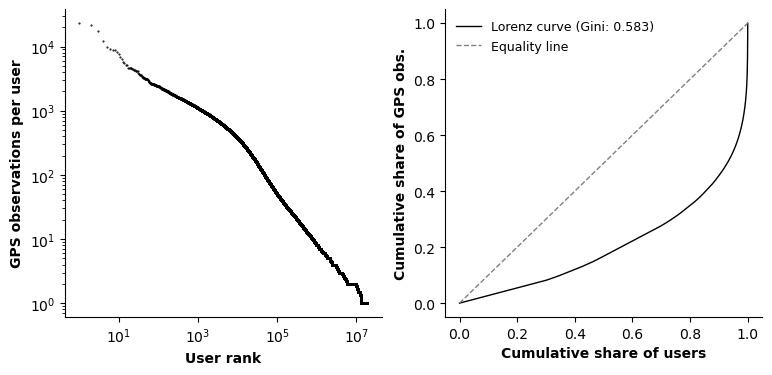

In [87]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

ranks = np.arange(1, len(df_user_gb_avg) + 1)
values = df_user_gb_avg["n_points"].values

#Rank–size plot (log–log)
axes[0].loglog(ranks, values, c="k", marker=".", linestyle="none", markersize=1)
axes[0].set_xlabel("User rank", weight=600)
axes[0].set_ylabel("GPS observations per user", weight=600)
#axes[0].set_title("Rank–size distribution of GPS points per user")

# Lorenz curve
values = np.sort(df_user_gb_avg["n_points"].values)
cum_points = np.cumsum(values)
cum_points = cum_points / cum_points[-1]

cum_users = np.arange(1, len(values) + 1) / len(values)
gini_score = round(gini(values), 3)
axes[1].plot(cum_users, cum_points, label=f"Lorenz curve (Gini: {gini_score})", c="k", linewidth=1)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Equality line", linewidth=1)

axes[1].set_xlabel("Cumulative share of users", weight=600)
axes[1].set_ylabel("Cumulative share of GPS obs.", weight=600)
#axes[1].set_title("Lorenz curve of GPS points per user")
axes[1].legend(loc="upper left", fontsize=9);

#for ax in axes:
#    ax.set_aspect('equal')

**Figure 17.** Rank–size distribution of total GPS observations per user, showing a pronounced heavy-tailed distribution in individual activity levels (left).
Lorenz curve depicting the cumulative share of GPS observations by ranked users (right), with the corresponding Gini coefficient (0.583) quantifying inequality in user-level contribution to total activity.

### 6.3 Effects of Point and Hexes Thresholds on Users

A vast majority of users exhibit very sparse daily activity (Figure 18). On an average day, approximately 28% of users generate at most one GPS point, nearly 50% record two or fewer points, and about 57% record three or fewer points. This share increases to 74% when considering users with ten or fewer daily points.

These figures indicate that most users contribute only limited and intermittent daily traces. Consequently, the dataset is not suitable for trajectory-level analyses of individual mobility. Any attempt to restrict the sample to “high-quality” users with sufficiently dense trajectories would require applying strict filtering criteria, which would substantially reduce the number of retained users and potentially introduce selection bias.


<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Points per User | Share of Users (%) |
| :------------------------:| :----------------: |
| ≤ 1                       | 28.42 ± 19.32      |
| ≤ 2                       | 49.58 ± 29.36      |
| ≤ 3                       | 56.54 ± 29.85      |
| ≤ 5                       | 65.48 ± 29.43      |
| ≤ 10                      | 73.81 ± 28.02      |

</div>
</div>

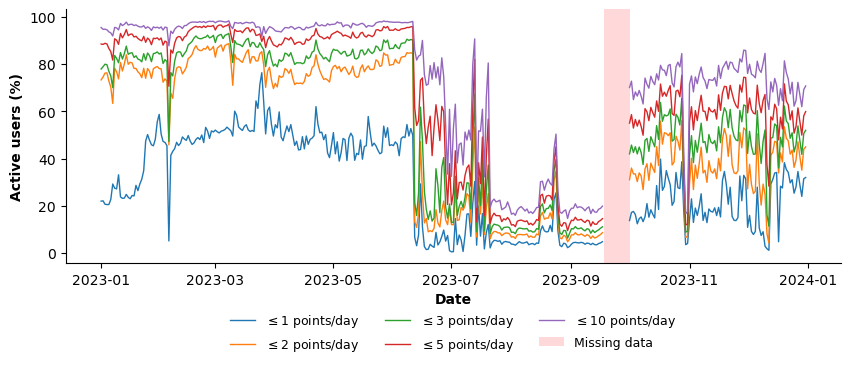

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2,3,5,10]
for th in list_ths:

    v_noise_pct = 100*(df_user_daily_summary[f"n_users_le_{th}"]/df_user_daily_summary["n_users"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    #print(f"users with <= {th} points {noise_avg} % (±{noise_std})")

    x_th, y_th = fill_time_gaps(df_user_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} points/day", linewidth=1)
    
    ax.set_xlabel("Date", weight=600);
    ax.set_ylabel("Active users (%)", weight=600);


ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=9);

**Figure 18.**
Daily percentage of users generating ≤1 (blue), ≤2 (orange), ≤3 (green), ≤5 (red), or ≤10 (purple) GPS observations. The shaded area denotes periods of missing data.


Most users are also spatially localized on a given day. On average, 81% of users visit at most one hex, and 88% visit two or fewer hexes. This pattern indicates that most daily activity reflects presence in a single location or a simple out-and-back pattern, rather than more complete trajectories. From a QA perspective, this behavior implies that user-level mobility metrics are likely to be data-sparse unless substantial temporal or spatial aggregation is applied, or minimum-activity thresholds are enforced (Figure 19). 

<div style="text-align: center;">
  <div style="display: inline-block; max-width: 100%; overflow-x: auto; text-align: left;">
      
| Number of Hexes per User| Share of Users (%) |
| :----------------------:| ------------------ |
| ≤ 1                     | 80.73 ± 20.04      |
| ≤ 2                     | 88.46 ± 16.85      |

</div>
</div>


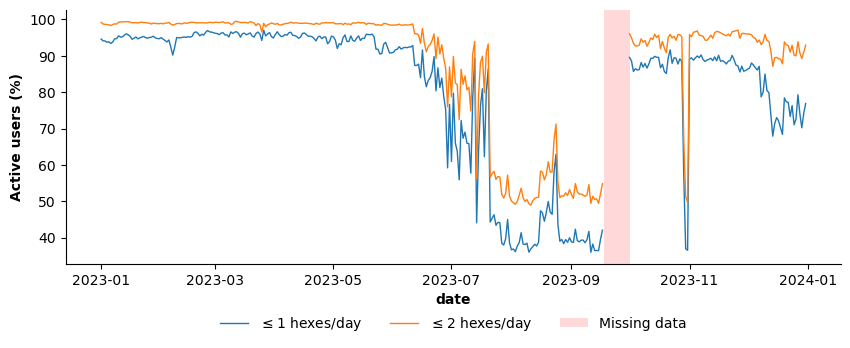

In [91]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3.3))

list_pcts = []
list_ths = [1,2]
for th in list_ths:

    v_noise_pct = 100*(df_user_daily_summary[f"n_users_hexes_le{th}"]/df_user_daily_summary["n_users"])
    noise_avg = round(np.mean(v_noise_pct), 2)
    noise_std = round(np.std(v_noise_pct), 2)
    list_pcts.append(noise_avg)
    #print(f"users with <= {th} hexes {noise_avg} % (±{noise_std})")

    x_th, y_th =  fill_time_gaps(df_user_daily_summary["date"], v_noise_pct.values, freq="D")
    ax.plot(x_th, y_th, label=f"$\leq${th} hexes/day", linewidth=1)
    
    ax.set_xlabel("date", weight=600);
    ax.set_ylabel("Active users (%)", weight=600);


ax.axvspan(missing_day_start, missing_day_end, color='red', alpha=0.15, linewidth=0, label="Missing data")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False);

**Figure 19.**
Daily percentage of users visiting ≤1 (blue) or ≤2 (orange) unique H3 hexagons. The shaded area denotes periods of missing data.


### 6.4 Data Quality Implications

User contributions follow a heavy-tailed distribution, meaning that averages are often dominated by a small subset of highly active users, while the behavior of low-activity users is under-represented. Where user-level comparability is required, analyses should rely on distribution-aware summaries (e.g., medians or quantiles) and stratify results by user activity level.

A large share of users generates sparse daily traces. In this dataset, about 50% of users record two or fewer points per day (and about 57% record three or fewer). As a result, the data are well-suited to analyses that interpret user presence as a signal of mobility or exposure within an area. In contrast, user-centric analyses requiring individual trajectories risk excluding a large fraction of low-active users.

On a given day, most users also exhibit highly localized spatial behavior. On average, approximately 81% of users visit at most one hex, and around 88% visit no more than two hexes. This pattern suggests that daily observations typically capture presence in a single location or a simple out-and-back movement, rather than complex multi-stop trajectories.

From a quality-assurance perspective, these characteristics are consistent with expectations for passively collected mobility data and support analyses based on user presence or relative intensity within areas. In summary, user presence provides a reliable coverage signal, whereas individual mobility metrics are not robust without substantial aggregation.

## 7. Data Quality Assessment Summary

This assessment evaluated the temporal, spatial, and user-level properties of the mobility dataset to determine its suitability for constructing an Urban Space Usage Index.

Overall, the dataset provides broad coverage and internally consistent aggregate signals. At the same time, it exhibits structural unevenness across time, space, and users that directly affects how indicators should be constructed and interpreted.

### 7.1 Temporal Dimension

The dataset achieves **high temporal coverage (96.68%) over 2023**. Outside of three identified anomalous intervals and a 13-day interruption in September, daily patterns of observations and visited spatial units remain broadly stable, while the number of active users exhibits greater day-to-day variability.

However, pronounced regime shifts reflect changes in tracking intensity and user coverage rather than clear behavioral mobility changes. These structural breaks limit direct longitudinal comparability. Raw time-series comparisons across different regimes are not valid without normalization.

For index construction, temporally stable regimes should be identified and treated consistently, and anomalous intervals should either be excluded or explicitly modeled.

### 7.2 Spatial Dimension

Spatial coverage is extensive (**67.92%**) but highly uneven. Activity is strongly concentrated in urban areas and follows a heavy-tailed distribution, with a small fraction of spatial units accounting for a disproportionate share of total observations.

Coverage is substantially weaker in rural and sparsely populated regions, where many spatial units exhibit persistently low activity. As a result, fine-grained spatial inference at high H3 resolutions is reliable primarily in dense urban cores. Spatial aggregation or population-aware normalization is required to ensure comparability outside these areas.

These characteristics are consistent with expectations for passively collected mobility data and do not invalidate the dataset, but they impose clear constraints on spatial resolution choices.

### 7.3 User Dimension

User contributions are highly heterogeneous. A small subset of highly active users accounts for a large share of observations, while most users produce sparse, localized daily traces: 50% generate 2 or fewer points per day.

This structure limits the robustness of individual-level mobility metrics and trajectory-based indicators without substantial aggregation or filtering. In contrast, aggregate presence-based measures at the spatial-unit level are considerably more stable and appropriate for index construction.

### 7.4 Overall Assessment

The dataset is suitable for constructing an Urban Space Usage Index when interpreted as a signal of relative presence and activity rather than as a comprehensive representation of individual mobility behavior.

Its principal strengths include large-scale coverage and stable aggregate dynamics within identified regimes. Its primary limitations arise from time-varying sampling intensity, uneven spatial representation, and user-level sparsity.


Accordingly, index construction should:

- Rely on temporally stable regimes or apply normalization across regimes;

- Apply spatial aggregation or population-aware adjustments in low-activity areas;

- Avoid reliance on individual-level trajectory metrics;

- Treat any annual baseline with caution, ensuring that structural regime shifts are explicitly accounted for.

When these safeguards are implemented, the dataset provides a reliable foundation for high-frequency monitoring of urban space usage.



#### Suitable and Non-Suitable Applications

**Suitable Applications**

The dataset is well-suited for:

- Aggregate, presence-based indicators of urban space usage

- Relative comparisons across locations within similar coverage regimes

- Urban and peri-urban analyses at daily or coarser temporal resolution

- Event- or shock-related analyses, provided anomalous periods are explicitly handled


**Non-Suitable Applications**

Without substantial aggregation or correction, the dataset is not well-suited for:

- Individual-level mobility profiling or behavioral inference

- Fine-grained trajectory reconstruction or detailed OD analysis

- Rural mobility indicators

- Longitudinal comparisons that assume stable sampling intensity over time


| **DO**                                                                                                                                                                                                                      | **DON’T**                                                                                                                                                                                         |
| --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Aggregate and smooth temporally** (for example, weekly or monthly aggregation; rolling averages) and **analyze within homogeneous data regimes** (baseline versus T1, T2, T3).                                            | **Do not attribute peaks or drops as real mobility effects** before verifying that they are not driven by tracking intensity, ingestion changes, or missing data periods.                 |
| **Interpret temporal trends jointly with diagnostic indicators** (active users, points per user, users per hex, regime flags) and explicitly document excluded or adjusted periods.                                         | **Do not attribute daily or short-term fluctuations to behavioral change** without normalizing for coverage variation and verifying regime stability.         
| **Use presence-based or relative metrics** (for example, active users per hex, share of total activity, standardized change relative to a local baseline) to improve comparability.                                         | **Do not treat raw point counts as measures of mobility volume** or as direct proxies for total population activity.                                                                              |
| **Correct for uneven spatial coverage** through population-aware normalization, stratification by urbanization level, or reporting per-capita or per-device rates.                                                          | **Do not compare raw mobility levels across regions**, particularly between urban and rural areas, without adjusting for sampling intensity and coverage differences.                             |
| **Match spatial resolution to data density** by applying finer H3 levels only where user density is sufficient and aggregating rural or peripheral areas to coarser spatial units when necessary.                           | **Do not conduct fine-grained spatial inference** in cells where daily activity is extremely low (for example, one or fewer users), as results will be statistically unstable and outlier-driven. |
| **For trajectory- or origin-destination-based analyses, enforce minimum data sufficiency thresholds** (for example, minimum number of points per day or minimum active window) and report sensitivity to threshold choices. | **Do not compute individual-level mobility or origin-destination metrics on sparse traces**, and do not apply aggressive filtering without explicitly assessing potential selection bias.         |

____

## 8. References

```{bibliography}
:style: unsrt
```